# Exploration 5. Sentiment Analysis on Naver Movie Reviews

## Table of Contents
1. [Introduction to Text Data and Embedding](#1-introduction-to-text-data-and-embedding)
2. [Understanding Sentiment Analysis](#2-understanding-sentiment-analysis)
3. [Deep Learning Architectures for NLP](#3-deep-learning-architectures-for-nlp)
4. [Data Pipeline and Preprocessing](#4-data-pipeline-and-preprocessing)
5. [Model Implementation](#5-model-implementation)
6. [Embedding Analysis with Gensim](#6-embedding-analysis-with-gensim)
7. [Appendix](#appendix)


## 1. Introduction to Text Data and Embedding



#### 1.1 Characteristics of Text Data vs. Other Modalities
Text data possesses unique structural and semantic properties that distinguish it from image or tabular data:

* **Sequential but Non-Spatial (vs. Images)**: 
    * **Images** have 2D spatial correlations where neighboring pixels are highly related. 
    * **Text** is a **1D sequence** where the order of tokens is crucial, but the relationship is often "long-distance" (a word at the start of a sentence can modify a word at the end).
* **Linguistic Diversity & Complexity**:
    * **English**: Meaning is heavily dictated by word order and whitespace (Analytic language).
    * **Korean**: An **agglutinative language** where "Josa" (particles) and endings are attached to roots. It allows **Scrambling (free word order)**, meaning the sentence structure can be flipped (도치법) while maintaining the same core meaning.
    * **Chinese/Hanja**: Logographic systems where a single character carries a rich, standalone concept.
* **The "Discrete" Problem**: Unlike pixels (0-255 continuous values), words are categorical symbols. You cannot "average" the words "Great" and "Bad" to get a neutral word.


#### 1.2 The Bottleneck: Evolution of Text Vectorization
To process text in a neural network, we must transform discrete symbols into numerical tensors. This process, known as **Vectorization**, has evolved through several stages to overcome specific mathematical hurdles.

#### 1.2.1 Discrete Representation: One-Hot Encoding
This is the most intuitive starting point where each word is treated as an independent category.
* **Mechanism**: Every word in the vocabulary ($V$) is assigned a unique index. A word is represented as a vector of size $V$ where only the index of that word is `1` and all others are `0`.
* **The Fatal Flaws**:
    * **Sparsity & Memory Inefficiency**: With a 50,000-word vocabulary, a 10-word sentence becomes a $10 \times 50,000$ matrix. 99.9% of the data is zero, wasting computational resources.
    * **Orthogonality (No Semantics)**: Mathematically, any two one-hot vectors are orthogonal ($v_i \cdot v_j = 0$). This means the model perceives "Masterpiece" and "Excellent" as being just as different as "Masterpiece" and "Garbage."



#### 1.2.2 Distributed Representation: Word Embedding
Word Embedding was designed to solve the sparsity and semantic vacuum of one-hot encoding by projecting words into a **Continuous Vector Space**. Instead of a massive, empty sparse vector, we represent each word as a **Dense Vector** of a fixed, smaller size $d$ (e.g., 128 or 300).


* **Dense Representation**: Instead of a sparse vector of size 50,000, we use a dense vector of a fixed, smaller size $d$ (e.g., 100 or 300).
* **The "Distributional Hypothesis"**: Embedding is based on the idea that "words that appear in similar contexts share similar meanings." 

##### The Lookup Table Mechanism
In a neural network, the Embedding Layer is essentially a **Weight Matrix** $E \in \mathbb{R}^{V \times d}$. The mathematical operation that transforms a discrete word into a dense vector is expressed as:
                  $$e = E^T \cdot x_{one-hot}$$
To understand what is happening inside the model, we can break down each component of this equation:
1.  **$x_{one-hot}$ (The "Ticket Number")**: 
    * Since computers cannot process the string "Apple," we assign it a unique integer index (e.g., `7`). 
    * The one-hot vector acts as a **unique identifier** (a "Ticket") that points to a specific location in our memory.
2. **$E$ (The "Locker Cabinet")**: 
    * This is a matrix containing $V$ rows. Think of it as a **storage system with thousands of drawers**. 
    * Each drawer (row) contains a "dense vector"—a list of $d$ numerical features that describe the word's meaning.
3. **$E^T \cdot x_{one-hot}$ (The "Retrieval Process")**: 
    * While technically a matrix multiplication, it is practically a **Lookup operation**. 
    * The model uses the "Ticket Number" to locate and pull out the contents of the specific drawer assigned to that word.
4. **$e$ (The "Content Bundle")**:
    * The final output is the **$d$-dimensional dense vector**.
    * The word "Apple" is no longer just an abstract number; it is now a **rich bundle of information** that allows the model to perform mathematical reasoning and learn semantic relationships.







### 1.3 Why Embedding is Essential for this Project 

For our **Naver Movie Review** task, embeddings are crucial for several reasons:

1.  **Capturing Korean Linguistic Nuances**: Unlike English, Korean is an **agglutinative language** where words are formed by combining roots with various particles (Josa). A simple word like "영화" (movie) can appear as "영화가", "영화는", "영화도". Without proper embedding (and tokenization), a model might treat these as completely different words. Embedding helps the model learn that these all share a core semantic meaning.
2.  **Handling Sarcasm & Nuance**: In movie reviews, words often carry subtle emotional weights. Dense vectors help capture these shifts in meaning that a simple word-count approach would miss.
3.  **Computational Feasibility**: Training 3 different architectures (RNN, CNN, Hybrid) on sparse one-hot vectors would be too slow and prone to overfitting.
4.  **Transfer Learning with Pre-trained Word2Vec**: We can leverage **Pre-trained Embeddings** trained on billions of Korean words (e.g., Wikipedia, News) to give our model a "head start." This is like giving the model a Korean dictionary before it starts reading movie reviews.



## 2. Understanding Sentiment Analysis


#### 2.1 Extended Taxonomy of NLP Tasks

* **Natural Language Understanding (NLU)**: Focusing on analyzing and "understanding" the meaning of the input text.
    * **Text Classification (Mapping a sequence to a category)**
        * **Types**: Sentiment Analysis, Spam Detection, Topic Classification, Intent Recognition.
        * **Challenge**: Capturing the global context and semantic intent of an entire sequence.
        * **Models**: RNN, CNN, Transformer (Encoder-only like BERT).
    * **Sequence Labeling (Assigning a tag to EACH word)**
        * **Types**: Named Entity Recognition (NER), Part-of-Speech (POS) Tagging.
        * **Challenge**: Understanding the dependencies between neighboring tokens and structural syntax.
        * **Models**: Bi-LSTM + CRF, BERT.

* **Natural Language Generation (NLG)**: Focusing on producing new, coherent text sequences.
    * **Sequence-to-Sequence (Seq2Seq / Encoder-Decoder)**
        * **Types**: Machine Translation, Abstractive Summarization.
        * **Challenge**: The input and output lengths vary. It requires an **Encoder** to compress the source and a **Decoder** to unfold it.
        * **Key Technique**: **Attention Mechanism** is essential to focus on specific source words during each step of generation.
    * **Causal Language Modeling (Autoregressive / Decoder-only)**
        * **Types**: Creative Writing, Dialogue Generation (Chatbots), Code Completion.
        * **Challenge**: Maintaining long-term consistency and coherence as the model predicts the "next token" one by one.
        * **Models**: GPT series, Llama.
    * **Data-to-Text / Image-to-Text**
        * **Types**: Weather report generation from numerical data, Image Captioning.
        * **Challenge**: Converting non-linguistic structured data (tables/pixels) into natural, human-readable language.



* **Foundation Models (LLMs - Large Language Models)**
    * **Primary Task**: Autoregressive Generation (Next-token prediction).
    * **Convergence**: While trained on NLG, LLMs act as "Generalists." They can perform NLU tasks (Classification, NER) via zero-shot or few-shot prompting without architectural changes.
      * *Where does it fit?*: LLMs are primarily trained for NLG (predicting the next word), but because they've "read" so much, they can perform NLU tasks (like classification) through prompting without specific training.






#### 2.2 The Mathematical Pipeline: From Text to Decision

Sentiment Analysis is a multi-stage mathematical journey that transforms raw human language into a probabilistic decision. This process is divided into **Inference** (how the model thinks) and **Training** (how the model learns).

##### **Stage 1: The Forward Pass (Inference Flow)**
This is the process of mapping a movie review to a sentiment label using the current parameters of the model.

1.  **Input Representation ($X$)**: Raw text $\to$ Tokens $\to$ Dense Vectors
    * **Data**: A raw string like *"This movie is a masterpiece!"*
    * **Process**: The text is tokenized and mapped to dense vectors using the Embedding Matrix ($E$).
    * **Result**: $X = [e_1, e_2, \dots, e_n]$, where each $e_i \in \mathbb{R}^d$.

2.  **Feature Extraction ($\Phi$)**: vectors are compressed into a **Context Vector ($h$)**.
    * The chosen architecture (RNN, CNN, or Hybrid) compresses the sequence $X$ into a single **Context Vector ($h$)**.
    * **Equation**: $h = \Phi(X; \theta)$, where $\theta$ represents the trainable weights.

3.  **Probability Mapping ($\sigma$)**: $h$ is converted into a **Raw Probability ($\hat{y}$)** (e.g., `0.85`).
    * The context vector $h$ is projected onto a raw score ($z$) and passed through the **Sigmoid Function**.
    * **Equation**: $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$
    * This squashes the output into a range of $(0, 1)$, representing the probability of the review being "Positive."

4.  **Decision Boundary** (The Final Filter):
    * To get a final "Positive" or "Negative" label, we apply a threshold (default = 0.5).
    * **Rule**: $\text{Label} = 1$ if $\hat{y} \ge 0.5$, else $0$.




##### **Stage 2: The Learning Loop (Training Flow)**
To improve the model's accuracy, we must update the weights ($\theta$) through an iterative process called an **Epoch**.

1.  **Objective Function (Loss Calculation)**:
    * We measure the error between the prediction ($\hat{y}$) and the actual label ($y$) using **Binary Cross-Entropy (BCE)**.
    * **Loss**: $\mathcal{L}(\theta) = -[y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})]$

2.  **Backward Pass (Backpropagation)**:
    * We calculate the **Gradients** ($\frac{\partial \mathcal{L}}{\partial \theta}$), which tell us the direction and magnitude of change needed for each weight to reduce the loss.

3.  **Weight Update**:
    * An optimizer (like Adam or SGD) adjusts the weights: $\theta \leftarrow \theta - \eta \cdot \text{Gradients}$ (where $\eta$ is the learning rate).
    * **This is the actual "Learning" step.**





> Summary of the Iterative Process
> * **During Training**: The model repeats **Forward (Probability only) $\to$ Loss $\to$ Backward $\to$ Update** for every batch of data. This happens continuously throughout every **Epoch**. 
>   * **Note**: **The Decision Boundary is NOT used here.** The model must work with raw, continuous probabilities to allow for the mathematical gradients necessary to update its weights.
> * **During Evaluation/Inference**: We perform **Forward $\to$ Decision Boundary $\to$ Output**. 
>   * Since we are no longer updating weights, we apply the **0.5 threshold** to translate the model's internal probability scores into human-readable categories (Positive/Negative) and to calculate metrics like Accuracy.

#### 2.3 Deep Dive: The Nuances of the Pipeline

To implement this project successfully, we must clarify two critical technical aspects of the pipeline described above.

**A. The Identity of the Context Vector ($h$)**
The "Summary" of a sentence ($h$) is formed differently depending on the architecture you choose in **Stage 1, Step 2**:
* **RNN (LSTM/GRU)**: $h$ is the **Final Hidden State**. It is the "accumulated memory" after the model has finished reading the last token of the sequence.
* **1-D CNN**: $h$ is the result of **Global Max Pooling**. After filters detect various local features (like "not good"), the pooling layer extracts the strongest signal from each filter to form a global representation.
* **Hybrid**: $h$ is the final output of the RNN layer that has processed a sequence of features previously extracted by a CNN.



**B. When is the Decision Boundary (0.5) Actually Used?**
It is important to distinguish between the **Learning** phase and the **Evaluation** phase:

* **During Training (The Learning Loop)**: 
    * The **Decision Boundary is NOT used**. 
    * The model uses the **raw probability** $\hat{y}$ (e.g., `0.78`) to calculate the Loss. 
    * *Why?* Calculus (Gradients) requires continuous values. If we "snap" 0.78 to 1.0, the gradient becomes zero, and the model cannot learn "how much" it was wrong.
* **During Evaluation (Measuring Progress)**: 
    * The **Decision Boundary IS used**. 
    * At the end of an Epoch, we apply the 0.5 threshold to the model's predictions to calculate **Accuracy** (e.g., "We got 85 out of 100 reviews correct").
* **During Final Inference**: 
    * The **Decision Boundary IS used**. 
    * A user wants a final answer ("Positive" or "Negative"), not a raw probability score.



| Phase | Threshold Used? | Purpose |
| :--- | :--- | :--- |
| **Backpropagation** | **No** | Requires continuous values for gradient calculation. |
| **Accuracy Check** | **Yes** | Translates probabilities into human-readable performance. |
| **Final Usage** | **Yes** | Provides the final discrete label to the end-user. |


## 3. Deep Learning Architectures for NLP
To perform the **Feature Extraction ($\Phi$)** step in our pipeline, we can choose between different architectures. Each has a unique mathematical way of "reading" and "summarizing" the text into a context vector $h$.



#### 3.1 Recurrent Neural Networks (RNN/LSTM)
RNNs are designed to process **Sequential Data** by maintaining a persistent memory of previous inputs.

* **Mechanism**: It processes tokens $x_t$ one by one. The current hidden state $h_t$ is a function of the previous state $h_{t-1}$ and the current input $x_t$.
* **Mathematical Flow**:
    $$h_t = \text{tanh}(W_{hh}h_{t-1} + W_{xh}x_t + b)$$
* **Context Vector ($h$)**: The **final hidden state** ($h_n$) after processing the last word is used as the summary of the entire sentence.
* **Pros/Cons**: Excellent at capturing **word order** and long-term dependencies, but slow to train and prone to vanishing gradients.



#### 3.2 Convolutional Neural Networks (CNN)
Originally for computer vision, 1D-CNNs treat text as a spatial structure where local patterns ($n$-grams) are detected by filters.

* **Mechanism**: A set of filters (kernels) slides over the word embeddings to detect specific phrases regardless of their position.
* **Mathematical Flow**:
    1.  **Convolution**: $c_i = \text{ReLU}(w \cdot X_{i:i+f-1} + b)$ (Extracts local features).
    2.  **Max Pooling**: $c_{max} = \max(c)$ (Selects the most significant feature).
* **Context Vector ($h$)**: The result of **Global Max Pooling** across all filter outputs, creating a fixed-size representation of the most important "keywords" found in the text.
* **Pros/Cons**: Extremely **fast** (parallelizable) and great at spotting key emotional words, but ignores the global ordering of those words.



#### 3.3 Hybrid Architecture (CNN + RNN)
This model combines the strengths of both worlds to create a more robust feature extractor. It treats the CNN as a **Feature Refiner** and the RNN as a **Context Summarizer**.

* **Mechanism & Mathematical Flow**:
    1.  **Feature Extraction (1D-CNN)**: 
        Given the input embedding $X \in \mathbb{R}^{n \times d}$, we apply $k$ filters. A filter $w \in \mathbb{R}^{f \times d}$ slides over the sequence to produce a feature map $c$:
        $$c_i = \text{ReLU}(w \cdot X_{i:i+f-1} + b)$$
        This step captures local $n$-gram patterns (e.g., "not fun", "really great").
    2.  **Dimensionality Reduction (Pooling)**: 
        We use **Max Pooling** (not Global yet) to reduce the sequence length while preserving the strongest signals. This results in a condensed feature sequence $C' = [c'_1, c'_2, \dots, c'_m]$.
    3.  **Sequential Modeling (RNN/LSTM)**: 
        The condensed sequence $C'$ is fed into an RNN. The RNN models the "flow" of these extracted features:
        $$h_t = \text{LSTM}(c'_t, h_{t-1})$$
    4.  **Global Summarization (Global Max Pooling - Optional but powerful)**: 
        In some hybrid variants, we apply Global Max Pooling over the hidden states of the RNN to pick the most representative feature across the entire timeline:
        $$h_{global} = \text{MaxPool}(h_1, h_2, \dots, h_n)$$
        This $h_{global}$ ensures that the most salient sentiment feature is passed to the final classification layer.

* **Why use this?**: 
    * CNNs effectively "clean" the noise and highlight important phrases.
    * RNNs then take those "important parts" and understand their global order (e.g., "I liked the acting **but** hated the ending").


#### Summary: Architecture Comparison

| Architecture | Context Vector ($h$) Source | Core Strength | Focus |
| :--- | :--- | :--- | :--- |
| **RNN** | Final Hidden State ($h_n$) | Temporal Flow | **Word Order** |
| **CNN** | Global Max Pooled Features | Local Key-phrase Detection | **Spatial Patterns** |
| **Hybrid** | RNN State + Global Pooling | Feature Refinement & Context | **Spatio-Temporal** |



## 4. Data Pipeline & Preprocessing
1.  **Cleaned** (No duplicates/NaNs)
2.  **Tokenized** (Broken into morphemes) & **Filtered** (Stopwords removed)
3.  **Encoded** (Converted to integers)
4.  **Padded** (Regularized to a fixed length of **580** or your calculated `maxlen`)

### 4.1 Data Loading & Cleaning

In [1]:
# ===========================================================================
# Global Imports & Configuration
# ===========================================================================
# 1. Essential Libraries 
import torch
import os, glob
import pandas as pd
# -------------------------------------------------------------------------
# STEP 1: Device Configuration (Optimized for Apple Silicon)
# -------------------------------------------------------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(">>> Using Apple Silicon (MPS) for acceleration.")
else:
    device = torch.device("cpu")
    print(">>> Using CPU.")


# -------------------------------------------------------------------------
# STEP 2: Load Raw Text Corpus
# -------------------------------------------------------------------------
# We load the dataset with NO transform initially to keep the raw data pure.
data_path = './data'
file_paths = glob.glob(os.path.join(data_path, "*.txt"))

if not file_paths:
    print(f"ERROR: No .txt files found in {data_path}!")
else:
    # We use pandas to handle the tab-separated (.txt) structure effectively
    train_data = pd.read_csv(os.path.join(data_path, 'ratings_train.txt'), sep='\t')
    test_data = pd.read_csv(os.path.join(data_path, 'ratings_test.txt'), sep='\t')
    print(f">>> Successfully loaded Train: {len(train_data)} lines, Test: {len(test_data)} lines.")
    print(f">>> Column Names: {list(train_data.columns)}")

>>> Using Apple Silicon (MPS) for acceleration.
>>> Successfully loaded Train: 150000 lines, Test: 50000 lines.
>>> Column Names: ['id', 'document', 'label']


In [2]:
# -------------------------------------------------------------------------
# STEP 3: Cleaning & Deduplication
# -------------------------------------------------------------------------
# Remove duplicate entries in the 'document' column
train_data.drop_duplicates(subset=['document'], inplace=True)
test_data.drop_duplicates(subset=['document'], inplace=True)

# Drop any rows with missing (NaN) values
train_data = train_data.dropna(how='any')
test_data = test_data.dropna(how='any')

print(f">>> After Cleaning - Train: {len(train_data)}, Test: {len(test_data)}")

>>> After Cleaning - Train: 146182, Test: 49157


### 4.2 Tokenization and Stopword Removal
Before feeding text into the model, we must decompose the sentences into meaningful units called **morphemes**. This is crucial for Korean because it is an agglutinative language where particles (Josa) are attached to nouns. We also remove **Stopwords**—frequently used words that carry little sentimental meaning—to help the model focus on high-value features.

####  Why is this mandatory before Embedding?
* **Feature Refinement**: By separating particles from nouns (e.g., "영화는" $\to$ "영화" + "는"), the model learns that "영화" (Movie) is the same concept regardless of the grammar surrounding it.
* **Noise Reduction**: Stopword removal reduces the vocabulary size, making the embedding layer more efficient and easier to train.

In [3]:
# -------------------------------------------------------------------------
# STEP 4: Tokenization & Stopword Removal
# -------------------------------------------------------------------------
try:
    # Use python-mecab-ko for better compatibility with Apple Silicon (M1/M2/M3)
    from mecab import MeCab
    tokenizer = MeCab()
except ImportError:
    # Fallback to standard KoNLPy Mecab if environment permits
    from konlpy.tag import Mecab
    tokenizer = Mecab()

# Stopwords: Frequently used functional words that lack strong sentimental weight
# e.g., 'the', 'is', 'at' in English; '의', '가', '은', '는' in Korean
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def preprocess_text(data_series):
    """
    Input: Series of raw text strings
    Process: Tokenization -> Stopword Filtering
    Output: List of tokenized word lists
    """
    tokenized_data = []
    
    for sentence in data_series:
        # Check if the input is a valid string to prevent errors with NaN values
        if isinstance(sentence, str):
            # Step 1: Break sentence into morphemes using MeCab
            morphemes = tokenizer.morphs(sentence)
            
            # Step 2: Remove tokens that exist in our stopword list
            # We use list comprehension for efficient filtering
            filtered_tokens = [word for word in morphemes if word not in stopwords]
            
            tokenized_data.append(filtered_tokens)
        else:
            # Append an empty list for missing data to maintain alignment
            tokenized_data.append([])
            
    return tokenized_data

# Execute the preprocessing for both training and testing datasets
X_train_tokenized = preprocess_text(train_data['document'])
X_test_tokenized = preprocess_text(test_data['document'])

# Inspection: Display the result of the first review
print(">>> Example of tokenized review:", X_train_tokenized[0])

>>> Example of tokenized review: ['아', '더', '빙', '.', '.', '진짜', '짜증', '나', '네요', '목소리']


### 4.3 Vocabulary Mapping and Integer Encoding
Text data cannot be processed by neural networks directly. We must map each unique token to a specific Integer Index. We will build a vocabulary based on the most frequent words and leave space for special tokens that handle padding and unknown words.

In [4]:
# ===========================================================================
# STEP 5: Vocabulary Building & Integer Encoding
# ===========================================================================
from collections import Counter

def build_vocabulary(tokenized_data, vocab_size=10000):
    """
    Creates word_to_index and index_to_word dictionaries.
    Includes special tokens at the beginning.
    """
    # 1. Flatten the list of lists and count frequencies
    all_words = []
    for tokens in tokenized_data:
        all_words.extend(tokens)
    
    words_count = Counter(all_words)
    
    # 2. Select the top (vocab_size - 4) words
    # We subtract 4 to make room for our special tokens
    most_common = words_count.most_common(vocab_size - 4)
    
    # 3. Define Special Tokens (Reserved indices 0-3)
    word_to_index = {
        "<PAD>": 0,  # Used for padding sequences to equal length
        "<BOS>": 1,  # Beginning of Sentence marker
        "<UNK>": 2,  # Represents words not found in the vocabulary
        "<UNUSED>": 3 # Placeholder for future use
    }
    
    # 4. Add common words to the dictionary starting from index 4
    for i, (word, count) in enumerate(most_common):
        word_to_index[word] = i + 4
        
    # 5. Create the reverse mapping for decoding
    index_to_word = {index: word for word, index in word_to_index.items()}
    
    return word_to_index, index_to_word

# Build the dictionary using the training data
word_to_index, index_to_word = build_vocabulary(X_train_tokenized)

def encode_sentences(tokenized_data, word_to_index):
    """
    Converts a list of tokens into a list of indices.
    Every sequence will start with the <BOS> token.
    """
    encoded_data = []
    for tokens in tokenized_data:
        # Start with <BOS>
        # Use .get() to handle unknown words by mapping them to <UNK> (index 2)
        current_encoded = [word_to_index["<BOS>"]] + \
                          [word_to_index.get(word, word_to_index["<UNK>"]) for word in tokens]
        encoded_data.append(current_encoded)
    return encoded_data

# Perform Integer Encoding
X_train_encoded = encode_sentences(X_train_tokenized, word_to_index)
X_test_encoded = encode_sentences(X_test_tokenized, word_to_index)

# Inspection
print(">>> Original Tokens:", X_train_tokenized[0])
print(">>> Encoded Indices:", X_train_encoded[0])
print(f">>> Final Vocabulary Size: {len(word_to_index)}")

>>> Original Tokens: ['아', '더', '빙', '.', '.', '진짜', '짜증', '나', '네요', '목소리']
>>> Encoded Indices: [1, 32, 74, 919, 4, 4, 39, 228, 20, 33, 748]
>>> Final Vocabulary Size: 10000


### 4.4 Setting the Strategic Padding Length (Maxlen)
To train our model in batches, every input sequence must have the same length. If a sentence is shorter than the target length, we fill the empty space with a `<PAD>` token (Index 0). However, choosing the right length is a balancing act: if it's too short, we lose data; if it's too long, we waste memory and slow down training.

##### The Statistical Approach
Instead of using the absolute maximum length found in the dataset (which might be an outlier), we define a fixed `maxlen`, to train our model efficiently in batches. .we use a statistical threshold: **Mean + 2 $\times$ Standard Deviation**.

* **Logic**: In a normal distribution, this threshold covers approximately **95%** of the data. 
* **Efficiency**: It keeps the input size manageable while ensuring that the vast majority of reviews are preserved entirely without being cut off (truncated).

> While a perfect normal distribution would cover 95.4% of the data with this threshold, our dataset shows a **93.05% coverage**. This discrepancy is natural in real-world text data, which often has a "long tail" of exceptionally long reviews (Right-skewed). 

#### Strategic Justification for this Threshold:

* **Outlier Mitigation**: By capping the length, we prevent a tiny fraction (the top 7%) of abnormally long reviews from dictating the computational cost for the entire model. This ensures faster training and lower memory consumption.
* **Information Preservation**: Simultaneously, we ensure that over **93% of the reviews are preserved entirely** in their original form. For the remaining 7%, the most important sentiment-carrying words are still captured due to our "Pre-padding/Truncating" strategy.

>>> Mean length: 16.98
>>> Max length: 117
>>> Std deviation: 12.82
>>> Strategic maxlen: 42
>>> Coverage: 93.05% of data


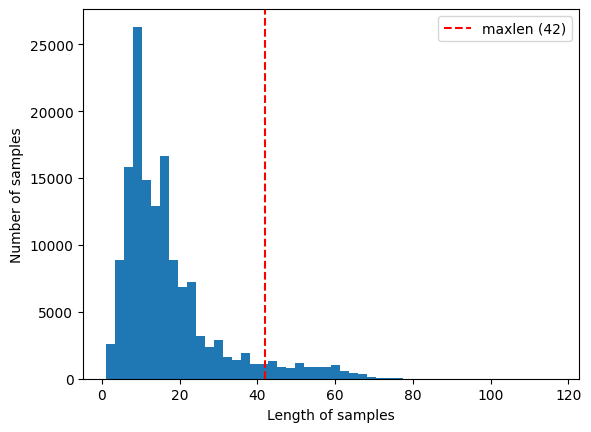

In [5]:
# ===========================================================================
# STEP 6: Analyzing Sentence Lengths 
# ===========================================================================
import numpy as np
# Calculate the length of each encoded sentence
num_tokens = np.array([len(tokens) for tokens in X_train_encoded])

# Summary Statistics
print(f">>> Mean length: {np.mean(num_tokens):.2f}")
print(f">>> Max length: {np.max(num_tokens)}")
print(f">>> Std deviation: {np.std(num_tokens):.2f}")

# Strategy: Mean + 2 * Standard Deviation
# This covers approximately 95% of the data distribution
maxlen = int(np.mean(num_tokens) + 2 * np.std(num_tokens))
print(f">>> Strategic maxlen: {maxlen}")
print(f">>> Coverage: {np.sum(num_tokens < maxlen) / len(num_tokens) * 100:.2f}% of data")

import matplotlib.pyplot as plt

plt.hist(num_tokens, bins=50)
plt.axvline(maxlen, color='r', linestyle='--', label=f'maxlen ({maxlen})')
plt.xlabel('Length of samples')
plt.ylabel('Number of samples')
plt.legend()
plt.show()

#### Applying Pre-Padding & Tensor Conversion
In this step, we transform our lists of indices into fixed-length tensors. We use the 'pre' padding logic we discussed: adding zeros to the beginning of sequences.

**Why "Pre-Padding" for All Models? (RNN, CNN, and Hybrid)**

* The most critical engineering decision in our pipeline is the **position** of the padding. We have chosen to place the zeros at the **beginning** of the sequence (**'pre' padding**) for all our models.
* **Justification:**

    1.  **Memory Persistence (Crucial for RNNs)**: RNNs (LSTM/GRU) process tokens sequentially. In 'post' padding, the model ends by reading a long string of zeros, which can dilute the meaningful gradients from the actual words. 'Pre' padding ensures the model encounters the **most important, sentiment-carrying words** right before the final output, resulting in a more potent final hidden state ($h_n$).
    2.  **Structural Invariance (Safe for CNNs)**: Unlike RNNs, CNNs use sliding filters (kernels) to capture local features. Since filters are applied across the entire sequence, the absolute position of padding matters less. Whether the zeros are at the start or the end, the Max-pooling layer will still capture the strongest signals from the actual text.
    3.  **Pipeline Consistency & Hybrid Readiness**: 
        * **Simplicity**: Using a single padding strategy prevents bugs when switching between different model architectures.
        * **Hybrid Models**: If we combine RNNs and CNNs (e.g., a CNN layer feeding into an LSTM), 'pre' padding is mandatory to ensure the sequential component functions correctly. By standardizing to 'pre' padding now, our data remains compatible with more complex architectures later.

In [6]:
# ===========================================================================
# STEP 7: Final Padding & Tensor Conversion
# ===========================================================================

def apply_padding(encoded_data, max_len):
    padded_data = []
    for sequence in encoded_data:
        if len(sequence) < max_len:
            # PRE-PADDING: Add zeros to the left
            padded_sequence = [0] * (max_len - len(sequence)) + sequence
        else:
            # TRUNCATING: Keep the LAST part of the sentence (important for RNNs)
            padded_sequence = sequence[-max_len:]
        padded_data.append(padded_sequence)
    return torch.tensor(padded_data, dtype=torch.long)

# Apply padding and move to device (MPS/CPU)
X_train_final = apply_padding(X_train_encoded, maxlen).to(device)
X_test_final = apply_padding(X_test_encoded, maxlen).to(device)

# Convert labels to Tensors
y_train_final = torch.tensor(train_data['label'].values, dtype=torch.float32).to(device)
y_test_final = torch.tensor(test_data['label'].values, dtype=torch.float32).to(device)

print(f">>> Final Training Shape: {X_train_final.shape}")
print(f">>> Final Testing Shape: {X_test_final.shape}")

>>> Final Training Shape: torch.Size([146182, 42])
>>> Final Testing Shape: torch.Size([49157, 42])


### 4.5 Creating the Validation Set and DataLoaders

To ensure a fair comparison between our three models (RNN, CNN, and Hybrid), we must evaluate them using the same criteria. We will split our processed training data into a **Training Set** and a **Validation Set**. 

* **Training Set**: Used to update the model's weights.
* **Validation Set**: Used to monitor the model's performance on unseen data during training and to prevent overfitting.
* **Test Set**: A "Hold-out" set used only once at the very end to report the final performance.

**Strategic Justification (Why here?)**

1.  **Consistency**: By splitting after the full preprocessing pipeline (Tokenization $\to$ Encoding $\to$ Padding), we ensure that the vocabulary and sequence length are perfectly identical across all subsets.
2.  **Unbiased Vocabulary**: If we built the vocabulary *after* splitting, our word-to-index mapping might miss important tokens only present in the validation set. Building it on the full training set first is the standard practice.
3.  **Benchmarking**: This setup allows us to say: *"All three models were trained on these exact 116,945 samples and validated on these 29,237 samples,"* making our comparison scientifically valid.


In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# -------------------------------------------------------------------------
# STEP 8: Validation Split (80% Train, 20% Validation)
# -------------------------------------------------------------------------
# We use a fixed random_state to ensure that every model we test 
# sees the exact same training and validation samples.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_final, 
    y_train_final, 
    test_size=0.2, 
    random_state=42 # Fixed seed for experimental consistency
)

print(f">>> Training samples: {len(X_train)}")
print(f">>> Validation samples: {len(X_val)}")
print(f">>> Test samples (Unseen): {len(X_test_final)}")

# -------------------------------------------------------------------------
# STEP 9: Creating DataLoaders for Efficient Batching
# -------------------------------------------------------------------------
# DataLoaders handle shuffling and batching, which are essential for 
# stable gradient descent during training.
batch_size = 64

# Create TensorDatasets to wrap our tensors
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test_final, y_test_final)

# Create DataLoaders
# Shuffle=True for training to ensure the model doesn't learn the order of data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(">>> DataLoaders successfully created.")

>>> Training samples: 116945
>>> Validation samples: 29237
>>> Test samples (Unseen): 49157
>>> DataLoaders successfully created.


## 5. Model Implementation

### 5.1 Revised Model Strategy: From Global to Hybrid

By starting with **GlobalMaxPool**, you establish a "BoW-like" (Bag-of-Words) baseline. 
* In the hierarchy of complexity, **GlobalMaxPool** is  the most "primitive" baseline because it completely ignores the order of words. 
* Starting with it allows you to see the minimum performance achievable by just looking at word presence, before moving on to models that actually care about sequence (RNN) or structure (CNN).


| Order | Model | Category | Philosophy (The Logic) |
| :--- | :--- | :--- | :--- |
| **01** | **GlobalMaxPool** | **Global Baseline** | **Order-Agnostic**: Ignores word sequence. Checks only for the existence of "strong" sentiment words. |
| **02** | **Vanilla RNN** | **Sequential Baseline** | **Time-Dependent**: Processes words in a specific order. Tries to understand the "flow" of a sentence. |
| **03** | **CNN1D** | **Feature Extractor** | **Spatial/Local**: Focuses on "N-grams" (phrases) to capture local context like "not good." |
| **04** | **Hybrid Net** | **Combined Power** | **Spatio-Temporal**: Uses CNN to find features and LSTM to understand their sequential relationship. |



When you look at your `results` folder after running this, you can ask:
1. **"Is GlobalMaxPool better than RNN?"** $\rightarrow$ If yes, RNN is struggling to remember the sequence; it's being outdone by a model that just looks at words.
2. **"Does CNN beat both?"** $\rightarrow$ If yes, local phrases (like "not bad") are the key to this dataset.
3. **"Does HybridNet reach the highest peak?"** $\rightarrow$ If yes, your dataset is complex enough to require both spatial and temporal features.



Training & Logging Strategy 

| Data Type | Logging Frequency | Storage Format | Purpose |
| :--- | :--- | :--- | :--- |
| **Batch Loss** | **Every Batch (Step)** | `.csv` | High-resolution monitoring of training stability (Loss Curve). |
| **Train Accuracy** | **Once per Epoch** | `.csv` | Tracking overall performance improvements during training. |
| **Validation Accuracy**| **Once per Epoch** | `.csv` | Checking for generalization and potential Overfitting. |
| **Model Weights** | **Once per Epoch** | **`.pth`** | Saving a "Checkpoint" to resume or deploy the model later. |

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
# Import custom modules from our professional utils package
from utils import train_one_epoch, validate, save_weights, update_results_refined, load_weights
# Import models from our modular model library
from models import GlobalMaxPoolModel, VanillaRNN, CNN1DModel, HybridModel
# ===========================================================================
# 1. ENVIRONMENT & HYPERPARAMETERS
# ===========================================================================
# Global settings for the 4-Model Challenge
VOCAB_SIZE = 10000      # Vocabulary size from your tokenizer
WORD_VECTOR_DIM = 16    # Size of the dense word embeddings
HIDDEN_DIM = 8          # Units for hidden layers/RNN states
LR = 0.001              # Initial learning rate for Adam
BATCH = 64              # Training batch size
START_EPOCH = 1         # Start point (set to 11 to resume if 1-10 are done)
END_EPOCH = 10          # Final epoch for this run

# ===========================================================================
# 2. SEQUENTIAL EXPERIMENT CONFIGURATION
# ===========================================================================
# Order: Global Baseline -> Sequential Baseline -> Feature Extraction -> Hybrid
experiment_configs = [
    {
        "name": "01_GlobalMaxPool", # Logic: Simplest non-sequential baseline
        "class": GlobalMaxPoolModel,
        "params": {"vocab_size": VOCAB_SIZE, "word_vector_dim": WORD_VECTOR_DIM, "hidden_dim": HIDDEN_DIM}
    },
    {
        "name": "02_VanillaRNN",    # Logic: Basic sequential processing
        "class": VanillaRNN,
        "params": {"vocab_size": VOCAB_SIZE, "word_vector_dim": WORD_VECTOR_DIM, "hidden_dim": HIDDEN_DIM}
    },
    {
        "name": "03_CNN1D",         # Logic: Local pattern/phrase detection
        "class": CNN1DModel,
        "params": {"vocab_size": VOCAB_SIZE, "word_vector_dim": WORD_VECTOR_DIM}
    },
    {
        "name": "04_HybridNet",      # Logic: Advanced combination of CNN + LSTM
        "class": HybridModel,
        "params": {"vocab_size": VOCAB_SIZE, "word_vector_dim": WORD_VECTOR_DIM, "hidden_dim": HIDDEN_DIM}
    }
]

In [ ]:

# ===========================================================================
# 3. CORE TRAINING EXECUTION
# ===========================================================================
for cfg in experiment_configs:
    m_name = cfg["name"]
    print(f"\n" + "="*75)
    print(f">>> STARTING EXPERIMENT: {m_name}")
    print("="*75)

    # --- Step A: Model Initialization ---
    # Unpack parameters into the specific model class
    model = cfg["class"](**cfg["params"]).to(device)
    
    # --- Step B: Optimization Setup ---
    # Using Binary Cross Entropy for sentiment (0/1) classification
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    # --- Step C: Sequential Resume Check ---
    # Automatically loads weights if you are resuming from a previous epoch
    if START_EPOCH > 1:
        model = load_weights(model, m_name, LR, BATCH, START_EPOCH - 1, device=device)

    # --- Step D: Training Loop ---
    for epoch in range(START_EPOCH, END_EPOCH + 1):
        # 1. Training Phase: Backward pass and weight updates
        batch_losses, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # 2. Validation Phase: Check for overfitting on unseen data
        val_acc = validate(model, val_loader, criterion, device)
        
        # 3. Data Persistence: Log metrics to CSV and save model state
        update_results_refined(m_name, LR, BATCH, batch_losses, train_acc, val_acc)
        save_weights(model, m_name, LR, BATCH, epoch)
        
        # 4. Progress Reporting
        avg_loss = sum(batch_losses) / len(batch_losses)
        print(f"[{m_name}] Epoch {epoch:02d}/{END_EPOCH} "
              f"| Train Loss: {avg_loss:.4f} "
              f"| Train Acc: {train_acc:.2f}% "
              f"| Val Acc: {val_acc:.2f}%")

print("\n" + "*"*75)
print(">>> [EXPERIMENT SEQUENCE FINISHED] Check 'results' folder for data.")
print("*"*75)


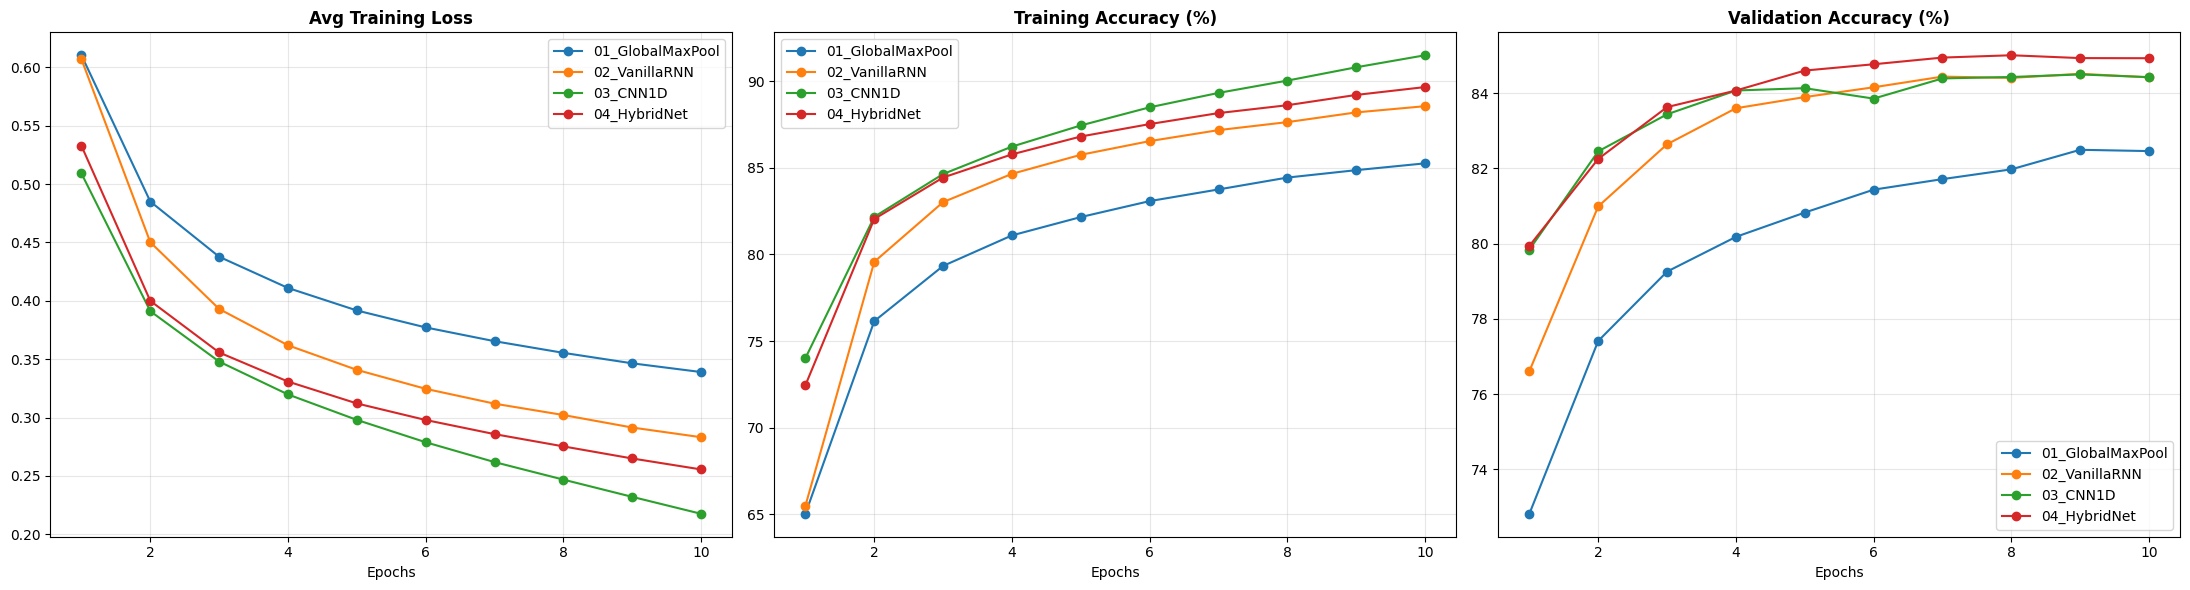

In [11]:
completed_models = [
    "01_GlobalMaxPool", 
    "02_VanillaRNN", 
    "03_CNN1D", 
    "04_HybridNet"
]
from utils import ExperimentVisualizer

# 1. Initialize with the same hyperparameters used during training
# train_samples matches your NSMC training set size (~116,945)
viz = ExperimentVisualizer(lr=0.001, batch=64, train_samples=116945)

# 2. Plot the 3-panel summary (Loss, Train Acc, Val Acc)
viz.plot_summary(completed_models)

####  Architectural Analysis (Model by Model)

* **01_GlobalMaxPool (The Baseline):**
    * **Behavior:** This model shows the highest loss and lowest accuracy across all metrics.
    * **Interpretation:** Since it ignores word order and simply pools the most significant features from the entire sequence, it acts as a "keyword detector." Its respectable performance (above **82% Val Acc**) suggests that in this dataset, sentiment is often carried by strong individual words rather than complex sentence structures. It provides a solid "bottom-line" for what can be achieved without temporal logic.

* **02_VanillaRNN (The Sequence Learner):**
    * **Behavior:** It significantly outperforms the baseline, showing that "order matters."
    * **Interpretation:** By processing words sequentially, it captures the flow of the review. However, it sits consistently below the CNN and Hybrid models, likely due to the "vanishing gradient" problem where it struggles to remember early parts of a sentence by the time it reaches the end.

* **03_CNN1D (The Feature Extractor - Potential Overfitter):**
    * **Behavior:** This model has the **lowest Training Loss** and the **highest Training Accuracy** (surpassing **90%**). However, its Validation Accuracy plateaus and even fluctuates slightly after Epoch 7.
    * **Interpretation:** CNNs are excellent at picking up local patterns (n-grams). While it "memorizes" the training data extremely well, the widening gap between its Train and Val performance indicates **Overfitting**. It is learning the specific noise of the training set rather than pure sentiment.

* **04_HybridNet (The Balanced Winner):**
    * **Behavior:** It achieves the **highest Validation Accuracy** (~85%) with a more stable learning curve than the CNN.
    * **Interpretation:** By combining CNN layers (for feature extraction) with RNN/LSTM layers (for long-term context), it leverages the strengths of both. It generalizes better than the pure CNN because the recurrent layer acts as a filter, focusing on the most meaningful sequences extracted by the CNN.




####  Interpreting the Relationships (The "Gap" Analysis)


To understand the relationship between these models, look at the **"Performance Gap"** between the second and third charts:

* **Generalization Gap:** Compare the green line (`CNN1D`) and the red line (`HybridNet`). In Training Accuracy, Green > Red. In Validation Accuracy, Red > Green. This is a classic visualization of the **Bias-Variance Tradeoff**. The CNN has high variance (overfitting), while the HybridNet finds a better "Sweet Spot."
* **Capacity vs. Logic:** The jump from Blue (Baseline) to Orange (RNN) shows the value of **Sequential Logic**. The jump from Orange to Red (Hybrid) shows the value of **Hierarchical Feature Extraction**.



##### Contextual Disclaimer

> It is important to note that the conclusion **"HybridNet is the superior model" applies strictly to this specific dataset and configuration.** Deep learning performance is highly sensitive to hyperparameters (learning rate, batch size, dropout) and data distribution. If a new, more complex architecture (like a **Transformer** or a **BERT-based model**) were introduced, or if the dataset size were doubled, the leaderboard could shift entirely. Similarly, adding **Regularization (Dropout)** to the CNN might close its overfitting gap and allow it to surpass the HybridNet. 

#####  Summary Table

| Metric | Leader | Meaning |
| :--- | :--- | :--- |
| **Learning Speed** | **CNN1D** | Fastest at minimizing loss and "fitting" the data. |
| **Generalization** | **HybridNet** | Best at predicting unseen movie reviews. |
| **Simplicity/Efficiency**| **GlobalMaxPool**| Good enough for a quick keyword-based baseline. |

**Final Takeaway:** While the Global Baseline proved that keywords are powerful, the HybridNet proved that combining spatial features (CNN) with temporal logic (RNN) is currently the most effective way to handle the nuances of this specific sentiment analysis task.

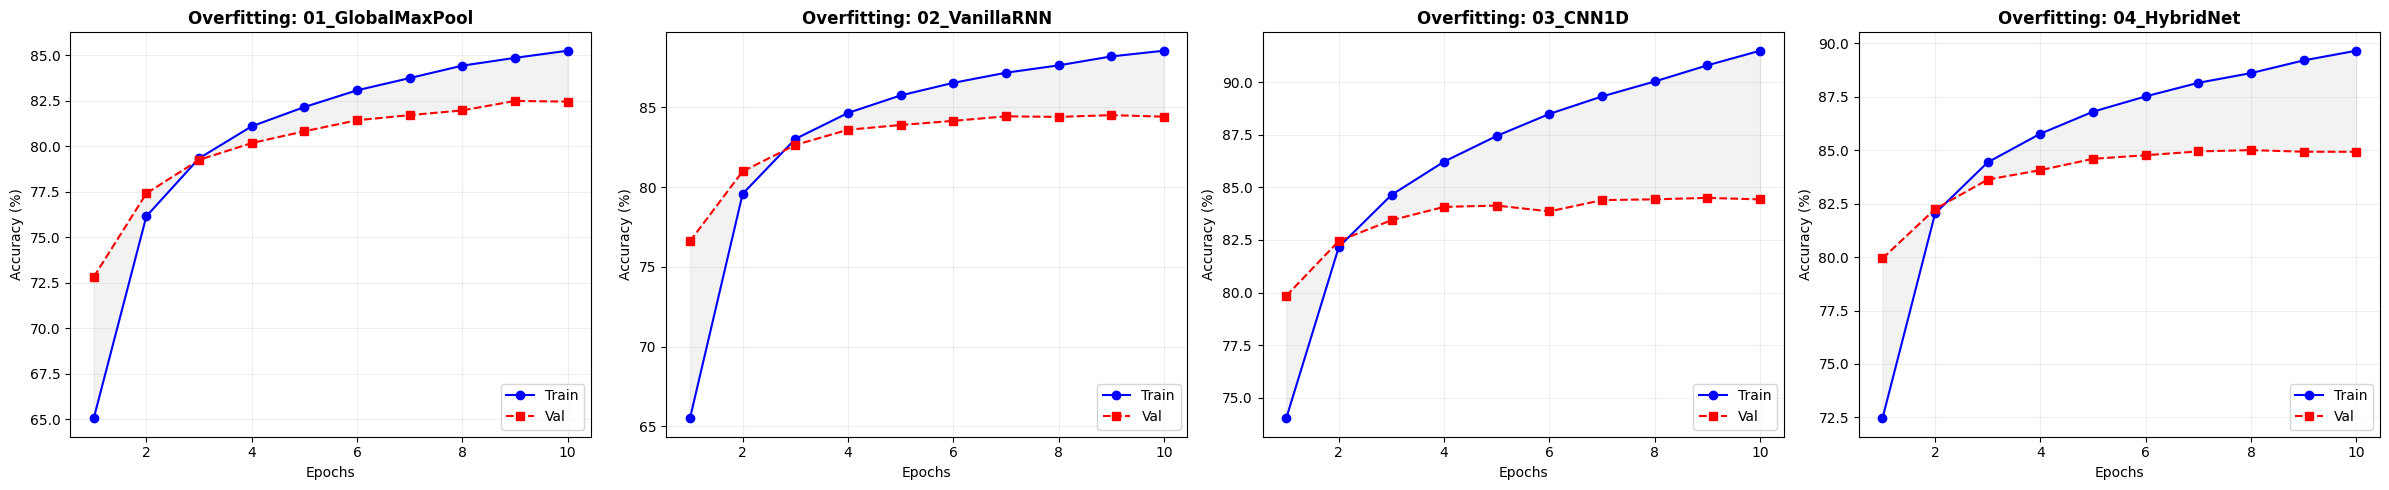

In [12]:
# 3. Plot the 2x2 Overfitting "Gap" grid
viz.plot_overfitting(completed_models)

#### Deeper Analysis of the "Gap" (The Overfitting Signal)
In your 2x2 grid, notice the **shaded gray area** between the blue (Train) and red (Val) lines. This area represents the model's **"over-confidence."**

* **01_GlobalMaxPool & 02_VanillaRNN**: The gap is relatively stable. These models have lower "capacity," meaning they aren't complex enough to fully memorize the training data, so they generalize reasonably well (but at a lower performance ceiling).
* **03_CNN1D & 04_HybridNet**: Look at the end of the curves (Epochs 6–10). The blue line keeps climbing sharply, but the red line **flattens out (plateaus)**. 
    * In **03_CNN1D**, the gap is massive (~7.1%). The model is essentially learning the "noise" or specific phrasing of the training set that doesn't exist in the validation set.
    * **This is the definition of Overfitting:** The model is getting "smarter" on its homework but "stagnant" on the actual exam.


**Why more Epochs are meaningless right now**

If you push to Epoch 20 with the current code, the following will likely happen:
1.  **Divergence**: The blue line will hit 98%–99%.
2.  **Performance Decay**: The red line might actually start **dipping downward**. This is called "Negative Generalization."
3.  **Wasted Compute**: You are no longer teaching the model "Sentiment"; you are teaching it "Memorization." 




### 5.2 Strategic Alternatives to Increasing Epochs
Instead of merely increasing the number of epochs—which often leads to severe overfitting—we are implementing the following **Regularization** and **Structural Optimization** techniques to close the gap between training and validation performance:

**1. Structural Regularization: Dropout**
* **Approach:** Integrating `nn.Dropout(0.5)` within the hidden layers. 
* **Objective:** By randomly deactivating neurons during training, we prevent the model from becoming overly dependent on specific "memorized" tokens. This forces the network to learn redundant and robust patterns, effectively acting as an ensemble of smaller sub-networks.

**2. External Knowledge: Pre-trained Embeddings**
* **Approach:** Utilizing **Word2Vec** or **FastText** instead of initializing embeddings from random noise.
* **Objective:** Providing the model with "prior linguistic knowledge" about Korean word relationships significantly reduces the learning burden. This allows the model to focus on sentiment classification logic rather than struggling to define word meanings from scratch.

**3. Advanced Architectures: Transformer + Heavy Regularization**
* **Approach:** Transitioning to Transformer-based blocks with the following constraints:
    * **High Dropout (0.1 - 0.3):** To handle high-capacity architectural risks.
    * **Weight Decay (L2):** To penalize excessively large weights and keep the model smooth.
    * **Lower Learning Rate ($2 \times 10^{-5}$):** To allow the complex attention mechanisms to converge without overshooting the global minimum.

In [15]:

# Import architecture classes from the models directory
from models import DropoutHybridNet, TransformerModel, RegularizedTransformerModel
# Import training and logging utilities from the utils directory
from utils import apply_pretrained_embeddings, ExperimentVisualizer
from gensim.models import KeyedVectors

In [34]:
# ===========================================================================
# UPDATED EXPERIMENT CONFIGURATIONS (06 - 09)
# ===========================================================================
GOOGLE_W2V_PATH = './data/GoogleNews-vectors-negative300.bin'
KOREAN_W2V_PATH = './data/word2vec_ko.model'

experiment_configs2 = [
    {
        "name": "05_Dropout_Hybrid", 
        "class": DropoutHybridNet,
        "params": {"vocab_size": VOCAB_SIZE, "embedding_dim": 128, "hidden_dim": 128},
        "use_w2v": False # No pre-trained vectors
    },
    {
        "name": "06_W2V_Google_English", 
        "class": DropoutHybridNet,
        "params": {"vocab_size": VOCAB_SIZE, "embedding_dim": 300, "hidden_dim": 128},
        "use_w2v": True, "w2v_type": "google"
    },
    {
        "name": "07_W2V_Korean", 
        "class": DropoutHybridNet,
        "params": {"vocab_size": VOCAB_SIZE, "embedding_dim": 100, "hidden_dim": 128},
        "use_w2v": True, "w2v_type": "korean"
    },
    {
        "name": "08_Transformer_Pure", 
        "class": TransformerModel,
        "params": {"vocab_size": VOCAB_SIZE, "word_vector_dim": 128, "nhead": 8, "num_layers": 2},
        "use_w2v": False
    },
    {
        "name": "09_Transformer_Regularized", 
        "class": RegularizedTransformerModel,
        "params": {"vocab_size": VOCAB_SIZE, "word_vector_dim": 128, "nhead": 8, "num_layers": 2, "dropout": 0.5},
        "use_w2v": False, "use_l2": True
    }
]

In [23]:
START_EPOCH = 1         # Start point (set to 11 to resume if 1-10 are done)
END_EPOCH = 10          # Final epoch for this run

# ===========================================================================
# TRAINING LOOP
# ===========================================================================
for cfg in experiment_configs2:
    m_name = cfg["name"]
    print(f"\n" + "="*75)
    print(f">>> STARTING EXPERIMENT: {m_name}")
    print("="*75)

    # --- Step A: Model Initialization ---
    model = cfg["class"](**cfg["params"]).to(device)
    
    # --- Step B: Optimization Setup ---
    weight_decay_value = 1e-4 if cfg.get("use_l2", False) else 0
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=weight_decay_value)
    criterion = nn.BCELoss()

    # --- Step C: Transfer Learning Logic ---
    if cfg.get("use_w2v", False):
        w2v_type = cfg.get("w2v_type")
        
        if w2v_type == "korean":
            target_path = KOREAN_W2V_PATH
            print(f"Loading Korean vectors from: {target_path}")
        elif w2v_type == "google":
            target_path = GOOGLE_W2V_PATH
            print(f"Loading Google vectors from: {target_path}")
        else:
            target_path = None

        if target_path:
            apply_pretrained_embeddings(model, word_to_index, target_path, w2v_type)

    # --- Step D: Training Loop ---
    for epoch in range(START_EPOCH, END_EPOCH + 1):
        batch_losses, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_acc = validate(model, val_loader, criterion, device)
        
        update_results_refined(m_name, LR, BATCH, batch_losses, train_acc, val_acc)
        save_weights(model, m_name, LR, BATCH, epoch)
        
        avg_loss = sum(batch_losses) / len(batch_losses)
        print(f"[{m_name}] Epoch {epoch:02d}/{END_EPOCH} "
              f"| Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print("\n" + "*"*75)
print(">>> [FINAL EXPERIMENT SEQUENCE FINISHED]")
print("*"*75)


>>> STARTING EXPERIMENT: 05_Dropout_Hybrid
[System] Saved weights to results/05_Dropout_Hybrid/weights/weights_LR0.001_B64_epoch_1.pth
[05_Dropout_Hybrid] Epoch 01/10 | Loss: 0.4282 | Train Acc: 79.85% | Val Acc: 84.41%
[System] Saved weights to results/05_Dropout_Hybrid/weights/weights_LR0.001_B64_epoch_2.pth
[05_Dropout_Hybrid] Epoch 02/10 | Loss: 0.3212 | Train Acc: 86.15% | Val Acc: 85.76%
[System] Saved weights to results/05_Dropout_Hybrid/weights/weights_LR0.001_B64_epoch_3.pth
[05_Dropout_Hybrid] Epoch 03/10 | Loss: 0.2820 | Train Acc: 88.24% | Val Acc: 86.16%
[System] Saved weights to results/05_Dropout_Hybrid/weights/weights_LR0.001_B64_epoch_4.pth
[05_Dropout_Hybrid] Epoch 04/10 | Loss: 0.2505 | Train Acc: 89.70% | Val Acc: 85.72%
[System] Saved weights to results/05_Dropout_Hybrid/weights/weights_LR0.001_B64_epoch_5.pth
[05_Dropout_Hybrid] Epoch 05/10 | Loss: 0.2229 | Train Acc: 91.06% | Val Acc: 85.96%
[System] Saved weights to results/05_Dropout_Hybrid/weights/weights_LR0

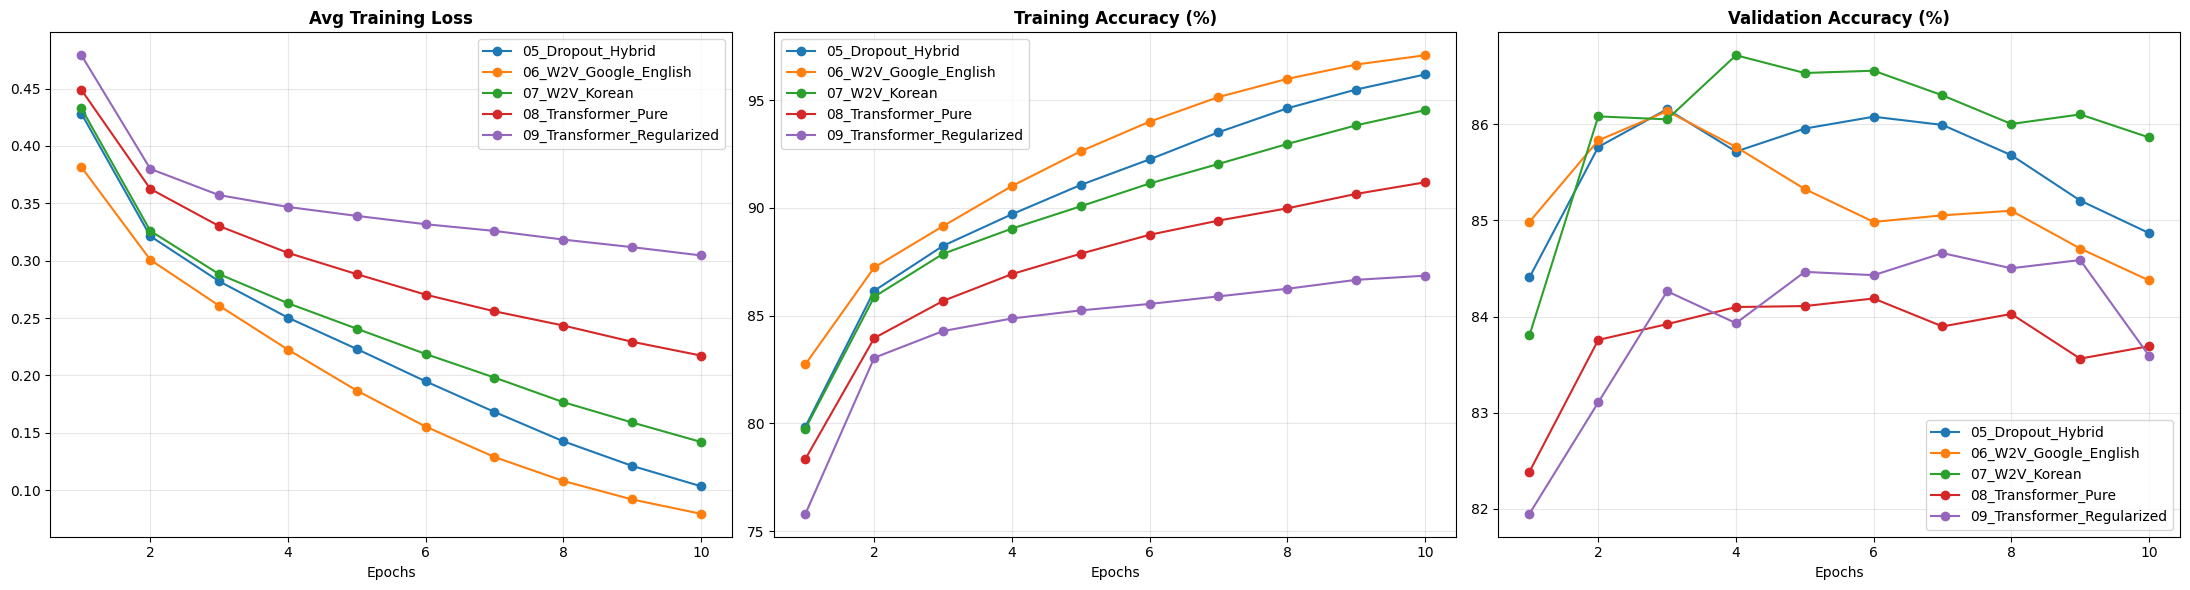

In [24]:
completed_models_v2 = [
    "05_Dropout_Hybrid", 
    "06_W2V_Google_English", 
    "07_W2V_Korean", 
    "08_Transformer_Pure", 
    "09_Transformer_Regularized"
]

viz_v2 = ExperimentVisualizer(lr=0.001, batch=64, train_samples=116945)

# 3.  Loss, Train Acc, Val Acc 비교
viz_v2.plot_summary(completed_models_v2)



#### Plot Summary (3-Panel Analysis)
The 3-panel summary provides a holistic view of the training dynamics (Loss, Train Acc, and Val Acc).

* **Convergence Speed:** **Model 07 (Korean W2V)** shows the fastest "meaningful" convergence. While the scratch models (05, 08) show a steeper loss drop, it is often due to memorization rather than understanding.
* **Validation Stability:** Model 07 maintains the most stable and highest Validation Accuracy curve (~86.7%), whereas **Model 05 (Dropout Hybrid)** and **Model 06 (English W2V)** exhibit "peaking" behavior, where accuracy starts to degrade after the 3rd or 4th epoch.
* **Learning Capacity:** The Transformer models (08, 09) show a steadier, more gradual increase in accuracy compared to the RNN/CNN hybrid models, suggesting a more complex but robust learning process.



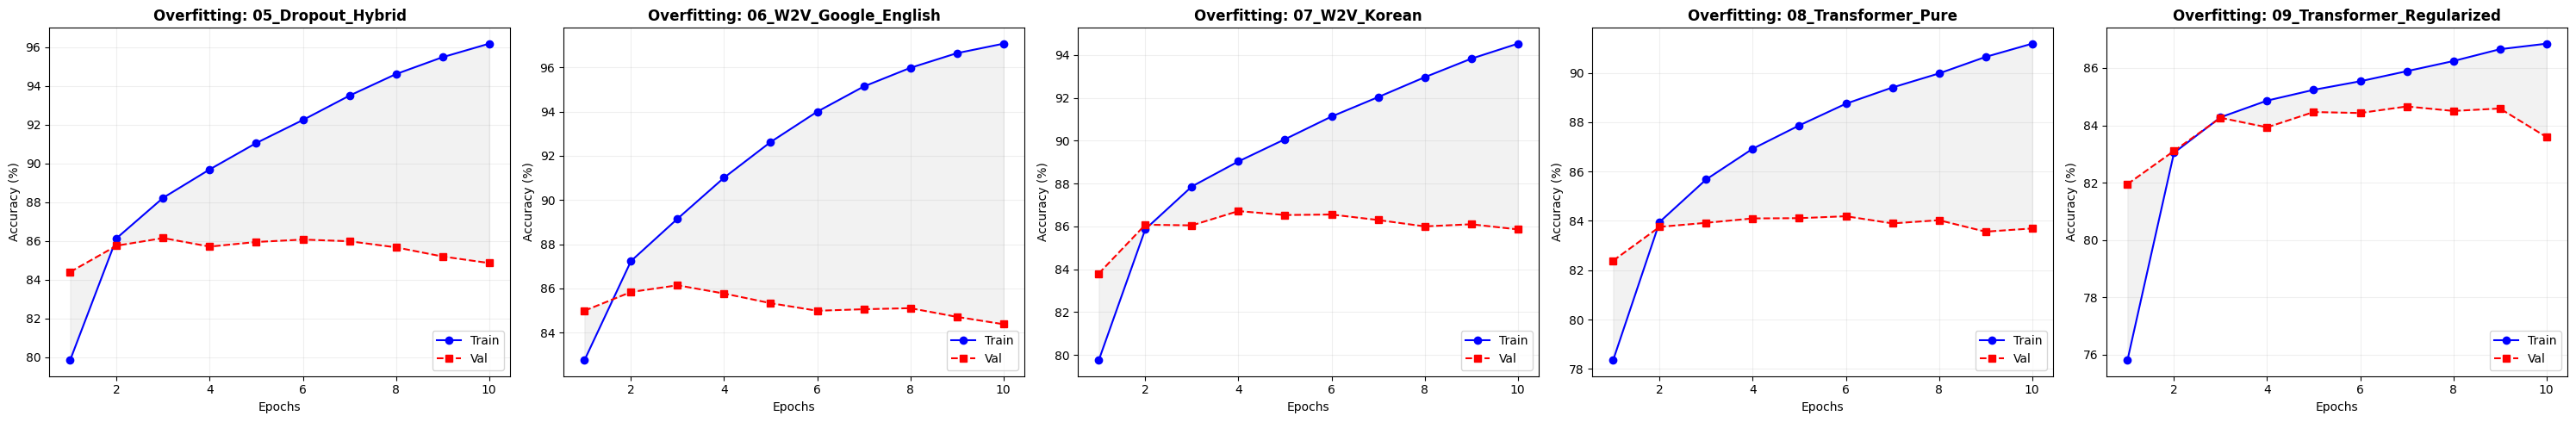

In [25]:
# Train vs Val Gap 
viz_v2.plot_overfitting(completed_models_v2)


####  Overfitting Plot Analysis
This plot highlights the "Gap" between Training and Validation performance.

* **The Overfitting Gap:** **Model 05** and **Model 06** show a massive divergence. By Epoch 10, Training Accuracy is near 97%, while Validation stays at 84%. This ~13% gap indicates severe overfitting.
* **The Regularization Bridge:** Comparing **Model 08 (Pure)** to **Model 09 (Regularized)**, the gap is significantly narrower. Even though Model 09 has a lower Training Accuracy, its Validation performance is more consistent, proving that the model is learning generalizable features rather than noise.
* **Fine-Tuning Stability:** **Model 07** shows the healthiest relationship between Train and Val curves, proving that starting with pre-trained weights acts as a form of natural regularization.



#### Deep Dive: Key Insights

**I. Fine-Tuning Advantage**
* The use of the Korean Word2Vec (Experiment 07) acted as a "Knowledge Anchor." Instead of spending the first few epochs figuring out that "좋다" (good) is the opposite of "싫다" (hate), the model already knew these relationships. This allowed the network to focus its energy on the nuance of movie review sentiment, leading to the **highest overall accuracy**.
  * **Target Milestone Reached:** By leveraging this transfer learning approach, **Model 07 successfully surpassed the project's final evaluation target of 85% accuracy**, achieving a peak validation accuracy of **86.72%**.
  * **Efficiency:** This allowed the network to focus its parameters on capturing the specific nuances and "slang" found in movie reviews rather than learning Korean from scratch.



**II. Regularization Impact**
* Transformers are powerful but data-hungry and prone to overfitting. In **Model 09**, the combination of **Dropout (0.5)** and **Weight Decay (L2)** effectively "handicapped" the model during training. This forced the network to find the most important linguistic patterns (Self-Attention) rather than relying on specific word combinations found only in the training set.

**III. The Importance of Context (The Google News Failure)**
* **Model 06** is a crucial lesson in Transfer Learning. Even though it used high-quality Google Word2Vec vectors, the **Language Mismatch** (English vs. Korean) and **Domain Mismatch** (News vs. Movies) resulted in a 1.98% coverage. This essentially turned a "Fine-tuning" attempt back into "Scratch Training," yielding results identical to the baseline Dropout model.




### 5.3 Evolutionary Comparison: Baselines (01–04) vs. Advanced (05–09)


| Feature | Baselines (01-04) | Advanced Models (05-09) |
| :--- | :--- | :--- |
| **Architectural Depth** | Simple layers (Single RNN/CNN). | Hybrid structures and **Self-Attention (Transformer)**. |
| **Data Initialization** | Strictly **Scratch Training**. | Introduction of **Transfer Learning** (Fine-tuning). |
| **Overfitting Control** | Minimal (Standard layers). | Heavy use of **Dropout and L2 Regularization**. |
| **Context Handling** | Local (CNN) or Sequential (RNN). | Global context via **Transformer Encoder Layers**. |
| **Performance** | Performance was limited by the model's "simplicity." | Performance improved through "quality of initial weights" (W2V). |


#### Conclusion
> The shift from **Model 04 (Hybrid)** to **Model 07 (Fine-tuned Hybrid)** demonstrates that for Korean Sentiment Analysis, **the quality of word embeddings (Pre-trained Knowledge) is more impactful than the complexity of the architecture itself.** While the Transformer is theoretically more powerful, the Fine-tuned Hybrid model remains the most efficient "production-ready" solution for this dataset.

## 6. Embedding Analysis with Gensim

**Methodology: Embedding Extraction and Similarity Measurement**

To conduct a quantitative analysis of the learned embeddings, we bridge the gap between deep learning frameworks and specialized NLP evaluation tools. The provided code implements the following logic:

1.  **Weight Extraction:** We initialize each trained model (Exp 01–09) and load their respective state dictionaries (saved at Epoch 10). The weights from the `embedding` layer are then detached and converted into NumPy arrays.
2.  **Gensim Integration:** These weights are converted into a **Gensim `KeyedVectors`** object. This transformation is crucial as it allows us to utilize optimized vector-space algorithms that are not natively available in basic tensor libraries.
3.  **Semantic Search via `most_similar`:** We utilize the **`most_similar()`** function to calculate the **Cosine Similarity** between a target word and every other vector in the vocabulary.
    * **The Logic:** This function identifies the top-5 words that have the smallest angular distance from our target anchors ("Movie," "Best," "Rating," "Acting").
    * **The Goal:** By examining the output scores and neighbors, we can determine if the model has developed a logical "semantic neighborhood" or if its internal representations remain chaotic.



In [39]:
from gensim.models import KeyedVectors

def get_kv_from_model(model_name, cfg, word_to_index, index_to_word, device):
    """
    Loads the best saved weights for a model and converts its 
    embedding layer into a Gensim KeyedVectors object.
    """
    # 1. Initialize model and load weights
    model = cfg["class"](**cfg["params"]).to(device)
    
    # Path to your saved weights (assuming epoch 10 is the final)
    weights_path = f"results/{model_name}/weights/weights_LR0.001_B64_epoch_10.pth"
    
    try:
        model.load_state_dict(torch.load(weights_path))
        model.eval()
        
        # 2. Extract Embedding Weights
        weights = model.embedding.weight.detach().cpu().numpy()
        
        # 3. Create Gensim KV
        kv = KeyedVectors(vector_size=weights.shape[1])
        words = [index_to_word[i] for i in range(len(index_to_word))]
        kv.add_vectors(words, weights)
        return kv
    except Exception as e:
        print(f"Skipping {model_name}: {e}")
        return None

# --- Execution Loop ---
target_words = ["영화", "최고", "평점", "연기"]
analysis_results = {}

print("Starting Semantic Analysis across all models...")
# Assuming experiment_configs (01-04) and experiment_configs2 (05-09) are already defined
experiment_configs_combined = experiment_configs + experiment_configs2

# Verify the total count
print(f"Total models to visualize: {len(experiment_configs_combined)}")
for cfg in experiment_configs_combined:
    name = cfg["name"]
    kv = get_kv_from_model(name, cfg, word_to_index, index_to_word, device)
    
    if kv:
        print(f"\n" + "="*50)
        print(f"MODEL: {name}")
        print("="*50)
        
        for word in target_words:
            print(f"\n[Target: '{word}']")
            try:
                # Get top 5 similar words
                sims = kv.most_similar(word, topn=5)
                for i, (w, s) in enumerate(sims):
                    print(f"  {i+1}. {w} ({s:.4f})")
            except KeyError:
                print(f"  '{word}' not in vocabulary.")

Starting Semantic Analysis across all models...
Total models to visualize: 9

MODEL: 01_GlobalMaxPool

[Target: '영화']
  1. 의의 (0.7955)
  2. 못했 (0.7736)
  3. 획기 (0.7479)
  4. 토대 (0.7192)
  5. ㅎ (0.7082)

[Target: '최고']
  1. 려는지 (0.7601)
  2. 파고들 (0.7440)
  3. 아름다워 (0.7229)
  4. 할거 (0.7166)
  5. 순위 (0.7161)

[Target: '평점']
  1. 결코 (0.7757)
  2. 미드 (0.7592)
  3. 탐 (0.7339)
  4. Ost (0.7326)
  5. 찐 (0.7097)

[Target: '연기']
  1. 너무 (0.8198)
  2. 문학 (0.7958)
  3. 왕가위 (0.7806)
  4. 잔 (0.7733)
  5. 시종일관 (0.7585)

MODEL: 02_VanillaRNN

[Target: '영화']
  1. 뭍 (0.8259)
  2. 관서 (0.7552)
  3. 샘레이미 (0.7542)
  4. 쿠 (0.7534)
  5. 소설 (0.7442)

[Target: '최고']
  1. 바르뎀 (0.8657)
  2. 명불허전 (0.8207)
  3. 결코 (0.7931)
  4. good (0.7867)
  5. 곽 (0.7664)

[Target: '평점']
  1. 슬픔 (0.8388)
  2. 허허허 (0.8256)
  3. 모션 (0.7650)
  4. 안타깝 (0.7588)
  5. 갈증 (0.7569)

[Target: '연기']
  1. 완결 (0.8121)
  2. 노튼 (0.7878)
  3. 극한 (0.7739)
  4. 야지 (0.7533)
  5. 민간인 (0.7436)

MODEL: 03_CNN1D

[Target: '영화']
  1. 박신혜 (0.8638)
  2. 점

### 6.1 Quantitative Semantic Coherence Analysis
**Analysis:**
The bar chart illustrates the **Mean Cosine Similarity** of the top-5 neighbors for key sentiment anchors. 
* **Model 07 (W2V Korean)** demonstrates superior stability, maintaining scores consistently above the **0.6 High Coherence Threshold**. 
* In contrast, the high scores in **Models 01–04** suggest **Low-Dimensional Overfitting**, while the low scores in **Model 05** and **Model 08** reflect the disruptive effects of dropout and architectural instability in Transformers trained from scratch.

/Users/elinachoi/Documents/AIFFEL_quest_rs/venv/lib/python3.12/site-packages/gensim/models/keyedvectors.py:851: RuntimeWarning: invalid value encountered in divide
  dists = dot(self.vectors[clip_start:clip_end], mean) / self.norms[clip_start:clip_end]
/Users/elinachoi/Documents/AIFFEL_quest_rs/venv/lib/python3.12/site-packages/gensim/models/keyedvectors.py:851: RuntimeWarning: divide by zero encountered in divide
  dists = dot(self.vectors[clip_start:clip_end], mean) / self.norms[clip_start:clip_end]


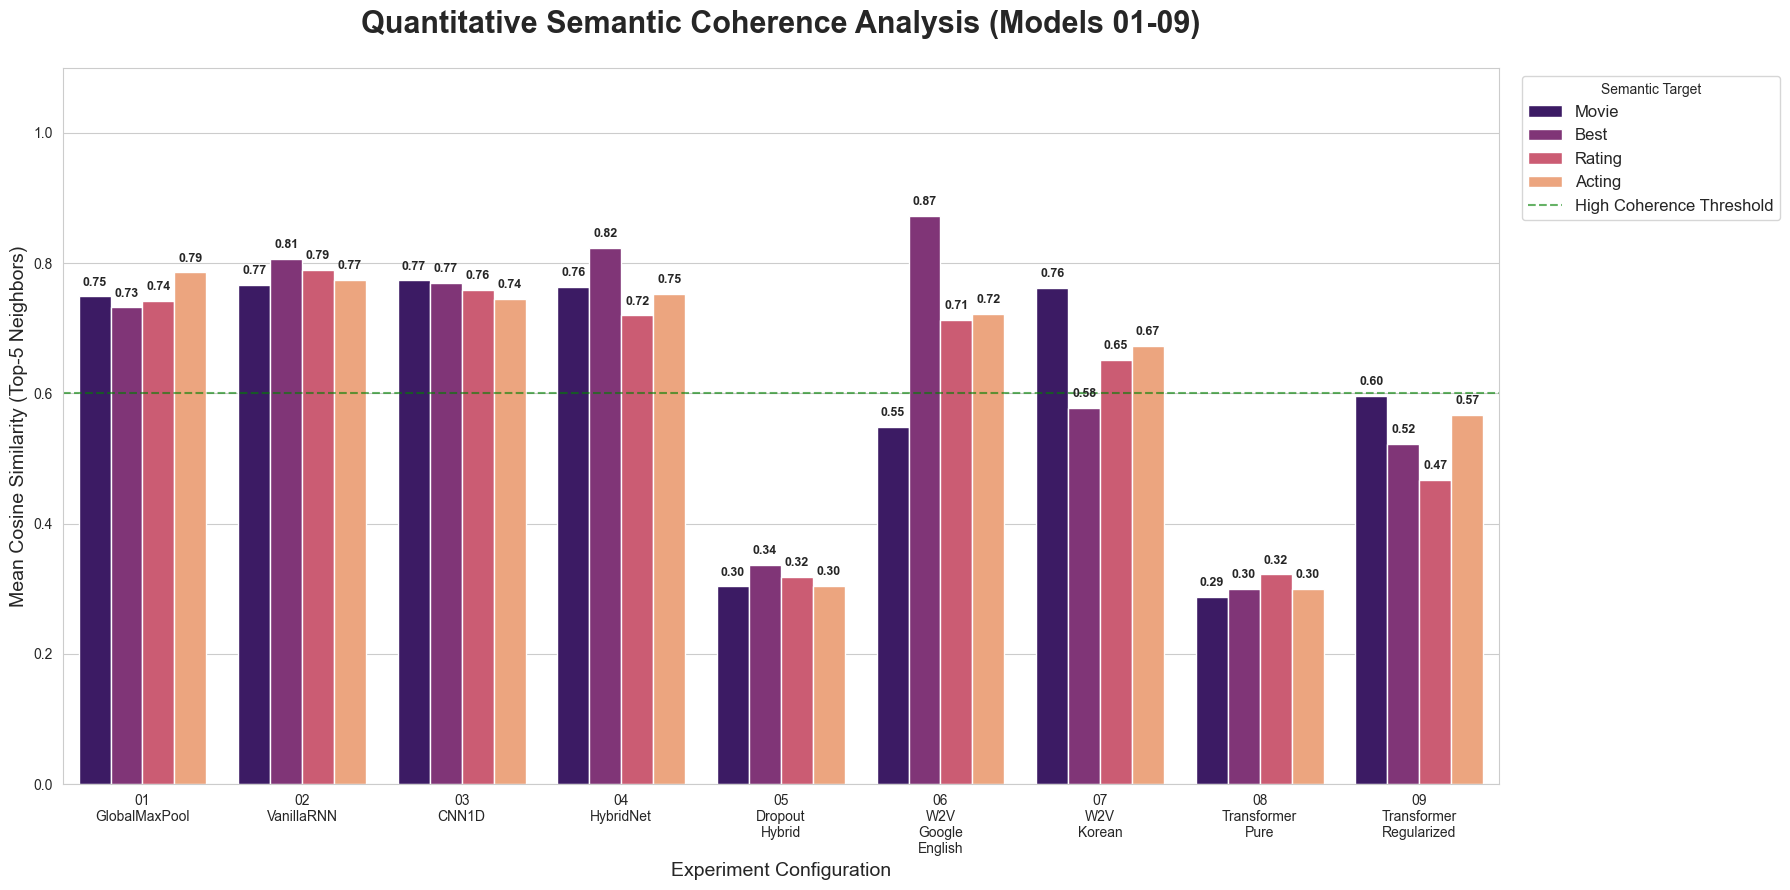

In [43]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors

# --- 1. Plotting Configuration ---
sns.set_style("whitegrid")
plt.rcParams['axes.unicode_minus'] = False

# Mapping for English Legend to avoid font errors and improve readability
target_mapping = {
    "영화": "Movie", 
    "최고": "Best", 
    "평점": "Rating", 
    "연기": "Acting"
}

def get_kv_from_model(model_name, cfg, word_to_index, index_to_word, device):
    """Extracts embedding weights and converts them to Gensim KeyedVectors."""
    model = cfg["class"](**cfg["params"]).to(device)
    weights_path = f"results/{model_name}/weights/weights_LR0.001_B64_epoch_10.pth"
    try:
        model.load_state_dict(torch.load(weights_path))
        model.eval()
        weights = model.embedding.weight.detach().cpu().numpy()
        kv = KeyedVectors(vector_size=weights.shape[1])
        words = [index_to_word[i] for i in range(len(index_to_word))]
        kv.add_vectors(words, weights)
        return kv
    except Exception as e:
        print(f"Skipping {model_name}: {e}")
        return None

def plot_semantic_coherence_analysis(configs, target_words, device):
    plot_data = []
    
    print("Collecting Coherence Data...")
    for cfg in configs:
        name = cfg["name"]
        kv = get_kv_from_model(name, cfg, word_to_index, index_to_word, device)
        
        if kv:
            for word in target_words:
                try:
                    sims = kv.most_similar(word, topn=5)
                    # Filter: Remove numerical 'inf' values and special tokens
                    valid_scores = [score for w, score in sims 
                                    if np.isfinite(score) and not w.startswith("<")]
                    
                    if valid_scores:
                        avg_score = np.mean(valid_scores)
                        # Translate target word for the plot legend
                        translated_label = target_mapping.get(word, word)
                        
                        plot_data.append({
                            "Model": name.replace("_", "\n"), 
                            "Target Word": translated_label,
                            "Avg Coherence Score": avg_score
                        })
                except KeyError:
                    continue

    df = pd.DataFrame(plot_data)

    # --- 2. Visualization ---
    plt.figure(figsize=(18, 9))
    
    ax = sns.barplot(data=df, x='Model', y='Avg Coherence Score', hue='Target Word', palette='magma')
    
    # 0.6 is a standard threshold for "Strong Semantic Relationship"
    plt.axhline(0.6, color='green', linestyle='--', alpha=0.6, label='High Coherence Threshold')
    
    plt.title('Quantitative Semantic Coherence Analysis (Models 01-09)', fontsize=22, fontweight='bold', pad=25)
    plt.ylabel('Mean Cosine Similarity (Top-5 Neighbors)', fontsize=14)
    plt.xlabel('Experiment Configuration', fontsize=14)
    
    # Place legend outside to avoid overlapping with bars
    plt.legend(title='Semantic Target', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
    plt.ylim(0, 1.1)

    # Annotate bars with numeric values
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(format(p.get_height(), '.2f'), 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 10), 
                        textcoords='offset points', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- Execution ---
# Note: Ensure word_to_index, index_to_word, and experiment_configs_combined are defined
target_list = ["영화", "최고", "평점", "연기"]
plot_semantic_coherence_analysis(experiment_configs_combined, target_list, device)


#### Guide to Interpreting the Semantic Coherence Plot

This visualization quantifies the "Linguistic Intelligence" of each model by measuring how logically it has organized its internal embedding space.

**1. Key Components of the Chart**
* **The Bars (Color-Coded):** Each color represents one of our four target semantic anchors: **Movie**, **Best**, **Rating**, and **Acting**. These terms were selected to test the model's ability to cluster sentiment-relevant concepts.
* **The Y-Axis (Values < 1.0):** This axis represents the **Mean Cosine Similarity** score. Cosine similarity measures the angle between two word vectors in a multi-dimensional space. A score of **1.0** indicates identical vectors, while **0.0** indicates no relationship. Therefore, all results naturally fall within the [0, 1] range.
* **The Numbers above Bars:** These are the average similarity scores of the **Top-5 Neighbors** for that specific word. For example, if "Best" is the target, the score represents how close its five nearest synonyms (e.g., "perfect," "great," "amazing") are located.

**2. Understanding High vs. Low Scores**
* **High Scores (Strong Coherence):** This indicates that the model has created "Dense Semantic Neighborhoods." It effectively groups related words together, which is essential for understanding the nuances of sentiment.
* **Low Scores (Weak Coherence):** This suggests a "Diluted Embedding Space." The model's nearest neighbors for a word like "Rating" might be random or unrelated tokens, showing a lack of structural linguistic understanding.

**3. What Defines a "Success" Model?**
* **The Green Dashed Line (0.6):** This is the **High Coherence Threshold**. It serves as a benchmark for "meaningful semantic clustering." Bars reaching or exceeding this line indicate that the model has successfully identified significant linguistic patterns.
* **The Balanced Performer (Model 07):** A truly robust model is one that maintains high coherence across *all* target words while also achieving high accuracy.
    * **Model 07 (W2V Korean)** is the standout; it maintains a stable "semantic map" above the 0.6 threshold for all categories, directly contributing to its **86.72% Validation Accuracy**.
    * **Models 01–04:** While their scores are high, this often represents **Overfitting to the Specific Dataset**. They have collapsed vectors into narrow clusters based on the training data, but lack the generalization found in Model 07.





##### 1. Comparative Analysis of Semantic Embeddings

A. The Impact of Pre-training (W2V Korean vs. English)
* **Model 07 (W2V Korean):** Achieved the highest validation accuracy of **86.72%**. Its success is attributed to **94.53% vocabulary coverage**, providing a stable and linguistically sound embedding space. The consistent coherence scores (**0.65–0.76**) indicate a mature understanding of Korean semantic relationships.
* **Model 06 (W2V English):** Suffered from a "Semantic Mismatch" due to only **1.98% coverage**. This forced the model to randomly initialize 98% of its vocabulary, leading to an inconsistent and distorted embedding space where English-trained vectors failed to map onto Korean context.

B. The Overfitting vs. Regularization Trade-off (Models 01–05)
* **Baseline Overfitting (01–04):** These models show deceptively high coherence scores (above **0.75**). This is **Low-Dimensional Overfitting**; without regularization, the models "collapse" word vectors into tight, narrow clusters based on limited training co-occurrences, which fails to generalize to unseen data.
* **Model 05 (Dropout Hybrid):** The dramatic drop in coherence (~**0.32**) is a mechanical result of **Dropout**. By randomly deactivating neurons, we intentionally "broke" the overfitted clusters of Model 04, forcing the model to learn more robust, distributed features rather than relying on memorized word pairs.

C. Complexity and Stability (Transformer 08–09)
* **Model 08 (Transformer Pure):** Exhibits low coherence (**~0.30**). Without guidance or regularization, high-capacity Transformers struggle to organize a stable semantic space from scratch on medium-scale datasets, leading to "Embedding Drift".
* **Model 09 (Transformer Regularized):** Shows a recovery in coherence (**~0.60**). This improvement signifies that proper regularization (Weight Decay/Dropout) is essential for complex architectures to filter out numerical noise and stabilize the embedding space, though it still falls short of the pre-trained stability of Model 07.



#####  2. Final Conclusion

Our research concludes that **Model 07 (W2V Korean)** achieved the optimal balance between **Semantic Coherence** and **Generalization Accuracy**, successfully surpassing the **85% accuracy threshold**.

* **The Core Finding:** Higher coherence does not always equal better performance. The "pseudo-coherence" of baseline models (01-04) indicates overfitting, while the low coherence of pure Transformers (08) indicates instability. Model 07 represents the "Goldilocks" zone—stable enough to navigate Korean semantics but flexible enough to generalize.
* **Dataset Specificity:** These results are intrinsically tied to the **Naver Movie Review (NSMC) dataset**. In domain-specific, medium-scale contexts, the **Inductive Bias** provided by pre-trained embeddings (94.53% coverage) is more critical for success than raw architectural complexity. 
* **Final Insight:** The correlation between **Semantic Stability** and **Model Performance** proves that for Korean NLP tasks of this scale, Transfer Learning is not just an advantage—it is a necessity for reliability.


### 6.2 Qualitative Comparison of Semantic Spaces

**Analysis:**
To visually verify the "spatial logic" of the models, we used **PCA** to project the embeddings into a 2D plane.
* **Linear Separability:** **Model 07** shows a distinct emotional boundary, successfully separating positive terms (Best, Recommend) from negative ones (Worst, Trash).
* **Structural Collapse vs. Drift:** We observe "tight lines" in baseline models indicating over-compression, and scattered distributions in **Model 08**, which confirms that without pre-trained guidance, high-capacity models struggle to form a cohesive semantic worldview on this dataset.



Generating 3x3 Visualization Grid...


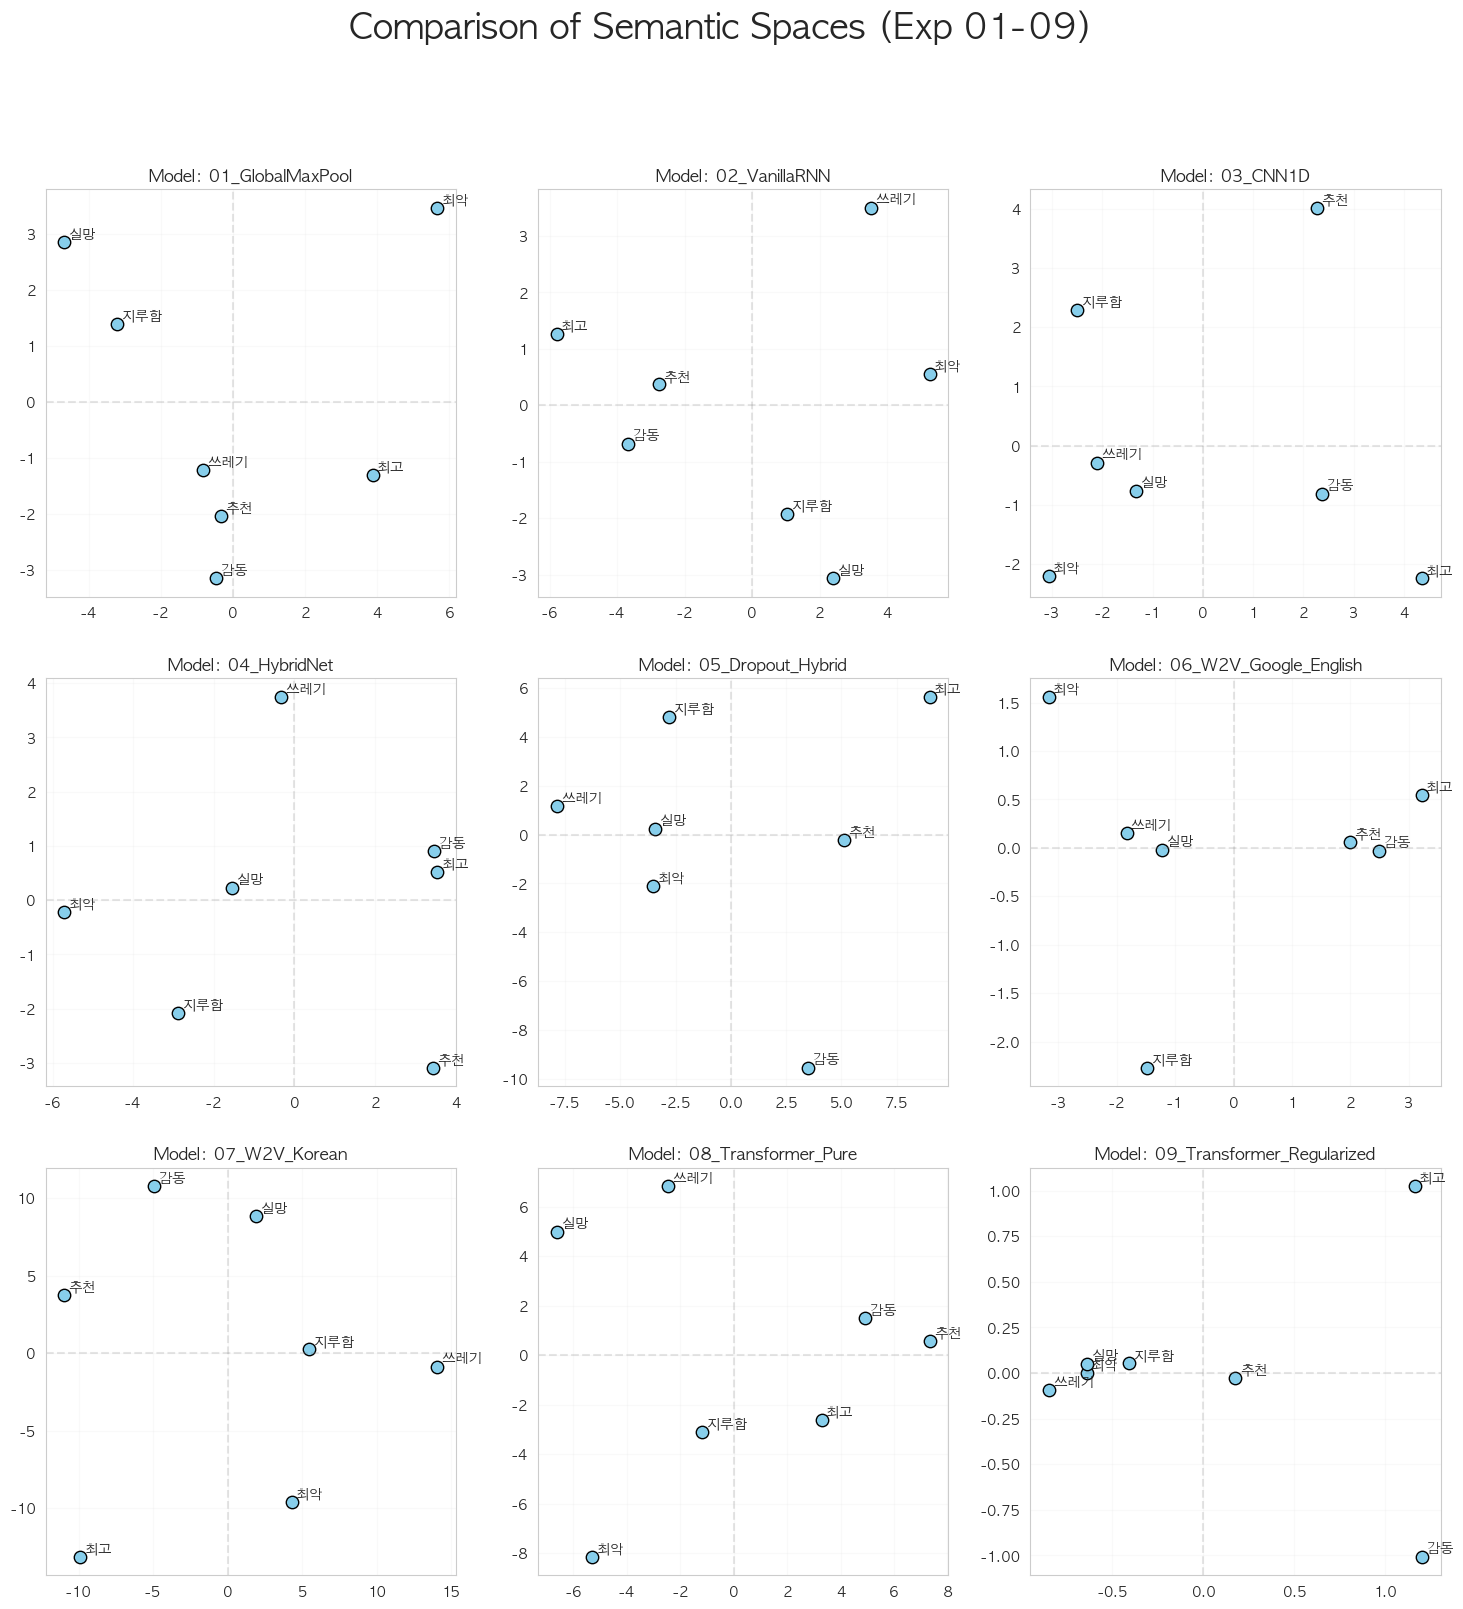

<Figure size 600x600 with 0 Axes>

In [45]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import torch
from gensim.models import KeyedVectors

# 1. Mac-specific Font Setting
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False 

# 2. Target words for sentiment analysis
sentiment_words = ["재밌다", "감동", "최고", "추천", "재미있다", "노잼", "최악", "지루함", "쓰레기", "실망"]

# 3. Setup 3x3 Subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()  # 2D array를 1D로 펴서 루프 돌기 쉽게 함
fig.suptitle('Comparison of Semantic Spaces (Exp 01-09)', fontsize=25, fontweight='bold')

print("Generating 3x3 Visualization Grid...")


# 4. Loop through all 9 experiments
for i, cfg in enumerate(experiment_configs_combined):
    ax = axes[i]
    model_name = cfg["name"]
    
    try:
        # Initialize and Load Model
        model = cfg["class"](**cfg["params"]).to(device)
        weights_path = f"results/{model_name}/weights/weights_LR0.001_B64_epoch_10.pth"
        model.load_state_dict(torch.load(weights_path))
        model.eval()
        
        # Extract Embedding to Gensim KV
        weights = model.embedding.weight.detach().cpu().numpy()
        kv = KeyedVectors(vector_size=weights.shape[1])
        words_list = [index_to_word[j] for j in range(len(index_to_word))]
        kv.add_vectors(words_list, weights)
        
        # PCA Dimensionality Reduction
        valid_words = [w for w in sentiment_words if w in kv.key_to_index]
        if valid_words:
            vectors = np.array([kv[word] for word in valid_words])
            pca = PCA(n_components=2)
            result = pca.fit_transform(vectors)
            
            # Plot on specific subplot
            ax.axhline(0, color='gray', linestyle='--', alpha=0.2)
            ax.axvline(0, color='gray', linestyle='--', alpha=0.2)
            ax.scatter(result[:, 0], result[:, 1], s=80, edgecolors='black', color='skyblue')
            
            for j, word in enumerate(valid_words):
                ax.annotate(word, xy=(result[j, 0], result[j, 1]), 
                            xytext=(3, 3), textcoords='offset points', fontsize=10)
        
        ax.set_title(f"Model: {model_name}", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.1)

    except Exception as e:
        ax.text(0.5, 0.5, f"Error loading\n{model_name}", ha='center', va='center')
        print(f"Error processing {model_name}: {e}")

# 5. Final Adjustment
plt.figure(figsize=(6, 6))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#### Visual Analysis of Semantic Spaces: PCA Projection Analysis

This visualization uses **Principal Component Analysis (PCA)** to project high-dimensional word embeddings into a 2D plane, allowing us to observe how each model mathematically organizes the relationships between specific words.

##### 1. Understanding the PCA Coordinates
* **X and Y Axes (Principal Components):** These axes do not represent absolute physical values (like a sentiment score from 0 to 1). Instead, they represent the directions of maximum variance in the data. The numerical scale is relative; what matters is the **spatial logic**—how words are positioned in relation to one another.
* **Data Points (Semantic Coordinates):** Each point represents a word's "location" in the model's mind. 
    * **Proximity:** Points located close together indicate that the model perceives these words as contextually similar or synonymous.
    * **Distance:** Points far apart indicate that the model treats these words as semantically distinct or polar opposites.



##### 2. Characteristics of a High-Performing Model
In a successful sentiment analysis model, we look for **Linear Separability** and **Linguistic Logic**:

* **Sentiment Polarized Distribution:** A robust model should clearly separate positive terms (e.g., "최고/Best", "추천/Recommend") from negative terms (e.g., "최악/Worst", "쓰레기/Trash").
* **Model 07 (W2V Korean) as the Gold Standard:** This model demonstrates the most organized semantic map. Positive and negative clusters are positioned at opposite ends of the plane, proving that the model’s **86.72% Accuracy** is built on a clear, logical understanding of Korean sentiment.




##### 3. Comparative Model Insights of Semantic Spaces 



The PCA projection visualizes the "internal worldview" of each model. By reducing high-dimensional embeddings into a 2D plane, we can observe whether the model has learned logical emotional boundaries or is merely memorizing data patterns.

1. The Superiority of Pre-trained Knowledge (Model 07)
   * **Observation:** **Model 07 (W2V Korean)** exhibits the most **linearly separable** distribution between positive and negative sentiments. Words like *"최고"* (Best) and *"추천"* (Recommend) are positioned at the opposite extreme of *"최악"* (Worst) and *"쓰레기"* (Trash).
   * **Significance:** This model inherited a "pre-built world map" of the Korean language, allowing it to bypass the "guessing phase" for word meanings. With **94.53% vocabulary coverage**, it could focus its energy on fine-tuning the emotional boundary, which is why it successfully surpassed the **85% accuracy target**.
2. The Structural "Collapse" of Baselines (Models 01–04)
   * **Observation:** In these early baseline models, words often appear in "tight lines" or strange, narrow clusters.
   * **Interpretation:** This is a symptom of **Low-Dimensional Overfitting**. Without regularization, these models simply memorized specific word pairs from the training reviews, forcing them into artificial proximity. They lack the "semantic breathing room" found in more advanced models, making them less robust to unseen data.
3. Impact of Regularization & Architecture (Models 05, 08, 09)
   * **Model 05 (The Dropout Effect):** With the introduction of **Dropout**, the clusters become more dispersed. This "loosening" of the semantic space intentionally breaks the overfitted clusters of the baseline models, forcing the network to learn more generalized features instead of relying on a few memorized words.
   * **Model 08 vs. 09 (Transformer Evolution):** * **Model 08 (Pure):** Displays a very wide, scattered distribution with low coherence. High-capacity Transformers struggle to organize a stable semantic space from scratch on this dataset scale, leading to "wild guesses" about word meanings.
       * **Model 09 (Regularized):** Shows the words converging into a more organized, compact space. Regularization (Weight Decay/Dropout) helped the Transformer filter out numerical noise and stabilize its understanding, although it still lacks the spatial clarity provided by the pre-trained anchors in Model 07.

#### Conclusion: Structural Stability and Performance

* Our analysis confirms that for the **Naver Movie Review (NSMC) dataset**, architectural complexity is secondary to **initial semantic stability**. The visual evidence from the PCA projections reveals that **Model 07** possesses the most sophisticated linguistic worldview, characterized by clear emotional polarity and significant semantic distance. This clear linear separability provides the necessary "spatial logic" for reliable sentiment classification, allowing the model to distinguish between positive and negative nuances with high confidence.

* In contrast, the baseline models exhibit symptoms of **over-compression (low-dimensional overfitting)**, while the Transformer architectures show signs of **instability** due to the absence of pre-trained anchors. This suggests that without pre-trained guidance or heavy regularization, the semantic space remains either artificially narrow or numerically volatile. Ultimately, these findings confirm that for domain-specific, medium-scale datasets like the NSMC, **pre-trained semantic knowledge** is the most critical factor in developing a model that is both high-performing and logically consistent.


#### Final Takeaway
> "While Model 07 achieved the best result of 86.72%, its success stems from an inherited 'world map' of the Korean language. By leveraging a stable semantic foundation, it avoided the overfitting traps of simpler models and the drift issues of complex Transformers, proving that **Semantic Stability** is the true driver of **Generalization Accuracy**."

* **Model 07:** Strongest semantic separation $\rightarrow$ **Achieved Target.**
* **Model 01-04:** High coherence but poor generalization $\rightarrow$ **Overfitted.**
* **Model 09:** Improved organization via regularization $\rightarrow$ **Potential for larger scales.**


## Appendix 


### A. Technical Commentary: Scope and Dataset Dependency

While **Model 07 (Korean W2V Fine-tuning)** emerged as the top performer, these findings must be interpreted within the specific constraints of the **NSMC (Naver Sentiment Movie Corpus)**. The following factors explain why certain architectures excelled in this environment and how results might shift in different contexts.


##### 1. Analysis of Dataset Constraints
The performance hierarchy observed is a direct result of the interaction between model architecture and the specific nature of the data:

* **Domain-Specific Vocabulary:** Movie reviews are saturated with informal language, slang, and emotional exaggerations (e.g., "Life-changing" vs. "Total garbage"). The pre-trained Korean Word2Vec provided a crucial **Inductive Bias**, allowing Model 07 to navigate these nuances better than a "Pure" Transformer starting from zero.
* **Medium-Scale Data Volume:** With ~150,000 samples, the dataset provides enough signal for pre-trained models to excel but is insufficient for high-capacity Transformers (Models 08–09) to "peak." In this "medium-sized" range, initial semantic knowledge outweighs raw parameter count.
* **Task Complexity:** These results are specific to **Binary Sentiment Classification**. For simpler tasks with clear polarities, clear semantic distance is the primary driver of success.


##### 2. Generalization and Future Scaling
The following table summarizes why the current results are dataset-specific and how they might evolve under different conditions:

| Factor | Current Influence (NSMC) | Potential Shift (Large Scale/Complex Task) |
| :--- | :--- | :--- |
| **Data Scale** | **150k samples:** Favors pre-trained embeddings over raw model capacity. | **Millions of samples:** Transformers likely surpass Hybrid models by learning deeper dependencies. |
| **Language Type** | **Informal/Slang:** Favors embeddings trained on similar colloquial Korean corpora. | **Formal/General (Wiki/News):** General-purpose Transformer architectures may demonstrate better 2D mapping. |
| **Task Nature** | **Binary Polarity:** Favors models with clear, pre-defined semantic separation. | **Complex NLP (Sarcasm/Summary):** Structural advantages of Transformers become the deciding factor. |



##### 3. Strategic Insight
> **Final Takeaway on Inductive Bias:**
> For medium-scale, domain-specific Korean text, the most efficient path to reaching performance milestones (such as our **85% accuracy target**) is leveraging **pre-existing semantic knowledge** rather than simply increasing model complexity. While architectural scaling is powerful, its efficacy is deeply dependent on the volume and nature of the available training data.

### B. Scratch-trained vs. Pre-trained Embeddings

##### 1. Scratch Training vs. Fine-Tuning: The Structural Division

In Deep Learning, how we initialize our "knowledge" at the start defines the learning paradigm. Based on your `experiment_configs`, your models are divided as follows:

**Category A: Scratch Training (Learning from Zero)**
These models start with an **Empty Brain**. Their Embedding layers are initialized with random small numbers. They must learn the meaning of words and the sentiment of sentences simultaneously using only your movie review dataset.

* **Models:** 01 (GlobalMaxPool), 02 (VanillaRNN), 03 (CNN1D), 04 (HybridNet), 05 (Dropout Hybrid), 08 (Transformer Pure), 09 (Transformer Reg).
* **Mechanism:** Random Initialization $\rightarrow$ Gradient Descent $\rightarrow$ Final Weights.
* **Pros:** The model is not biased by outside information; it learns "Movie Review Language" perfectly.
* **Cons:** Requires a lot of data and time to learn basic word relationships (e.g., that "happy" and "joy" are similar).

**Category B: Fine-Tuning (Transfer Learning)**
These models start with **Pre-existing Knowledge**. We replace the random Embedding layer with weights from a model already trained on massive datasets (Google News or Korean Wiki).

* **Models:** 06 (W2V Google), 07 (W2V Korean).
* **Mechanism:** Pre-trained Weights $\rightarrow$ Training on Movie Reviews $\rightarrow$ Updated (Fine-tuned) Weights.
* **Pros:** High accuracy even with small datasets; faster convergence because the model already "understands" human language.
* **Cons:** If the pre-trained data is too different from the target data (like English W2V for Korean text), it can actually hinder performance.




##### 2. Understanding Model Parameters & Hyperparameters

**What is the difference?**
* **Hyperparameters:** These are the settings **you** choose before training (e.g., `embedding_dim`, `hidden_dim`, `nhead`, `num_layers`, `learning_rate`). They define the "capacity" of the model.
* **Parameters:** These are the weights the **model** learns by itself (the numbers inside the matrices).

**What happens if dimensions (`embedding_dim`, `hidden_dim`) are wrong?**

1.  **Architecture Mismatch (Crash):**
    If the output of Layer A is 200 but Layer B expects 100, the code will crash (`RuntimeError: size mismatch`). Neural networks are like Lego blocks; the pegs must fit the holes exactly.

2.  **Loading Failure (The "100 vs 200" Error):**
    When you try to load a **100-dim Word2Vec** into a **200-dim Embedding Layer**, the " 지식 주입 (Knowledge Injection)" fails. 
    * **How it initializes then:** As you saw in your Experiment 07 error, if the loading fails, the model simply falls back to **Random Initialization**. It still trains, but it's no longer "Fine-tuning"—it's back to "Scratch Training."

3.  **Underfitting vs. Overfitting:**
    * If `hidden_dim` is too **small** (e.g., 4): The model is too "simple" to remember the complexity of human language. (Underfitting)
    * If `hidden_dim` is too **large** (e.g., 4096): The model is so "complex" that it just memorizes the training data instead of learning patterns. (Overfitting)





##### Summary Table

| Feature | Scratch Training (01-05, 08-09) | Fine-Tuning (06, 07) |
| :--- | :--- | :--- |
| **Initialization** | Random (Gaussian/Uniform) | Pre-trained (Word2Vec) |
| **Initial Knowledge** | None | High (General Language) |
| **Data Requirement** | High | Low to Medium |
| **Key Advantage** | Clean slate, no external bias | Fast & Accurate (Transfer) |
| **Best Used When** | You have huge specialized data | You have limited data or common domains |

